# Regional Population Evaluation

Region-stratified GTEx LORO diagnostics split out from `eval_population.ipynb`. This notebook owns tissue-level summaries and region fan plots.


## Table of Contents

- Notebook Configuration
- Shared Reconstruction
- Global Prediction Tables
- Region-Stratified Performance
- DLAM Gene-Highlighted Region Fan


In [1]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "src").exists() and (REPO_ROOT.parent / "src").exists():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.eval_utils.eval_population import *


In [2]:
%matplotlib inline

import importlib
import src.eval_utils.eval_style as eval_style
import src.eval_utils.eda_core as eda_core
import src.eval_utils.eval_population as eval_population
importlib.reload(eval_style)
importlib.reload(eda_core)
importlib.reload(eval_population)
from src.eval_utils.eval_style import *
from src.eval_utils.eval_population import *


## Notebook Configuration

All knobs live in the next cell. Copy this notebook, edit the config, and "Restart & Run All".


In [3]:
# === Global config ===
set_academic_style()

# Switch this one value when comparing cache families.
#   c        = centroid matching, covariate-aware ComBat
#   cv       = centroid+volume matching, covariate-aware ComBat
#   cv_nocov = centroid+volume matching, no ComBat covariates
CACHE_VARIANT = 'cv'  # 'c' | 'cv' | 'cv_nocov'
CACHE_VARIANTS = {
    'c': dict(
        cache_root='out/loro_subject_cache_c',
        combat_use_covariates=True,
        matching_policy='centroids',
        matching_policy_hemi_mode='force_left',
        collapse_cerebellum=False,
    ),
    'cv': dict(
        cache_root='out/loro_subject_cache_cv',
        combat_use_covariates=True,
        matching_policy='centroids_and_volumes',
        matching_policy_hemi_mode='force_left',
        collapse_cerebellum=False,
    ),
    'cv_nocov': dict(
        cache_root='out/loro_subject_cache_cv_nocov',
        combat_use_covariates=False,
        matching_policy='centroids_and_volumes',
        matching_policy_hemi_mode='force_left',
        collapse_cerebellum=False,
    ),
}
CACHE_CFG = CACHE_VARIANTS[CACHE_VARIANT]

CFG = EDAConfig(
    csv_path='data/raw/gxp_samples.csv',
    cache_root=CACHE_CFG['cache_root'],
    gene_scope='allgenes',
    combat_use_covariates=CACHE_CFG['combat_use_covariates'],
    matching_policy=CACHE_CFG['matching_policy'],
    matching_policy_hemi_mode=CACHE_CFG['matching_policy_hemi_mode'],
    collapse_cerebellum=CACHE_CFG['collapse_cerebellum'],
    gtex_rep_mode='centroid',
    gtex_hemi_mode='mirror_left',
)
print('cache variant:', CACHE_VARIANT)
print('cache root:', CFG.cache_root)
print('analysis scope:', CFG.gene_scope)
print('combat_use_covariates:', CFG.combat_use_covariates)
print('matching:', CFG.matching_policy, CFG.matching_policy_hemi_mode, 'collapse_cerebellum=', CFG.collapse_cerebellum)

MODELS                       = ['naive', 'dlam', 'plam']
N_JOBS                       = 16
CACHE_GLOBAL_TABLES          = True
FORCE_REBUILD_GLOBAL_TABLES  = False

VIEW_SUBSET = dict(
    genes=None, subjects=None, tissues=None,
    region_groups=None, sex=None, age=None,
)

DEFAULT_METRIC               = 'pearson_r'   # pearson_r | spearman_r | r2 | rmse

# --- Gene list (None = all genes from the cached tables) ---
EVAL_GENE_LIST_PATH          = None  # default: all genes. Sublist override e.g. 'gtex_100hvg', 'syngo', 'richiardi2015'

# --- Metric defaults ---
TABLE_METRICS                = ['pearson_r', 'r2', 'rmse']
DISTRIBUTION_KIND            = 'box'                        # 'box' | 'violin'

# --- Stratified scatter ---
SCATTER_MAX_POINTS_PER_MODEL = 100_000
SCATTER_BALANCED_SAMPLING    = True
SCATTER_RANDOM_SEED          = 42


cache variant: cv
cache root: out/loro_subject_cache_cv
analysis scope: allgenes
combat_use_covariates: True
matching: centroids_and_volumes force_left collapse_cerebellum= False


## Shared Reconstruction

`PREPOST` is rebuilt here because fold-combo summaries and cache/table metadata need target metadata and observed-region structure.


In [4]:
PREPOST = prepare_pre_post_harmonization_cached(CFG)
print('subjects:', len(PREPOST['subjects']))
print('genes:', len(PREPOST['genes']))
print('parcels:', PREPOST['raw_cube'].shape[1])


[prepost_cache] hit  notebooks/cache/prepost/0f8616c23cf88e0f.pkl  (8961.2 MB)
subjects: 318
genes: 11704
parcels: 150


## Global Prediction Tables

Build or load the canonical all-gene wide evaluation tables. The truth and prediction tables share identical `subject_region_key` row order.


In [5]:
truth_df, pred_dfs, global_manifest = build_global_prediction_tables(
    cfg=CFG,
    prepost=PREPOST,
    models=MODELS,
    cache=CACHE_GLOBAL_TABLES,
    force_rebuild=FORCE_REBUILD_GLOBAL_TABLES,
    n_jobs=N_JOBS,
)

manifest_summary = {
    k: global_manifest.get(k)
    for k in [
        'created_at_utc',
        'cache_dir',
        'source_cache_root',
        'gene_scope',
        'models',
        'truth_expression_space',
        'prediction_expression_space',
        'gtex_rep_mode',
        'gtex_hemi_mode',
        'n_rows',
        'n_genes',
        'n_subjects',
        'n_parcels',
    ]
}
display(pd.Series(manifest_summary, name='global_eval_manifest'))
display(truth_df.head())
print({model: df.shape for model, df in pred_dfs.items()})


created_at_utc                                  2026-05-22T02:08:38.642135+00:00
cache_dir                      /scratch/asr655/neuroinformatics/Seq2GeneEx/gt...
source_cache_root                                      out/loro_subject_cache_cv
gene_scope                                                              allgenes
models                                                       [naive, dlam, plam]
truth_expression_space                                                harmonized
prediction_expression_space                                           harmonized
gtex_rep_mode                                                           centroid
gtex_hemi_mode                                                       mirror_left
n_rows                                                                      2869
n_genes                                                                    11704
n_subjects                                                                   318
n_parcels                   

,subject,age,sex,subject_region_key,parcel_idx,gtex_region,ahba_region,region_group,gtex_coordinates_raw,gtex_rep_x,...,ZSWIM9,ZW10,ZWILCH,ZWINT,ZXDA,ZXDC,ZYG11B,ZYX,ZZEF1,ZZZ3
0,GTEX-1117F,64.0,F,GTEX-1117F|4,4,brain - cerebellar hemisphere,Cerebellar_Region4,cerebellar,"[(-26.04206099, -53.60357518, -51.26077813), (...",-33.487977,...,6.466657,3.419601,3.177844,3.086900,3.508116,4.255570,4.933786,5.259330,5.524441,4.210621
1,GTEX-1117F,64.0,F,GTEX-1117F|10,10,brain - caudate (basal ganglia),LH-Ca,subcortical,"[(-13.71428571, 6.556257901390637, 8.983565107...",-14.216461,...,6.412849,3.488853,3.104949,2.829613,3.571098,4.336617,4.975995,4.836494,5.504370,4.260066
2,GTEX-1117F,64.0,F,GTEX-1117F|18,18,brain - nucleus accumbens (basal ganglia),LH-NAC,subcortical,"[(-9.566666667, 7.900000000000006, -9.53333333...",-9.934848,...,6.340438,3.478578,3.001925,2.706913,3.589927,4.373537,4.939840,4.933590,5.530099,4.283050
3,GTEX-1117F,64.0,F,GTEX-1117F|19,19,brain - putamen (basal ganglia),LH-Pu,subcortical,"[(-25.11581292, 0.3563474387527776, 0.59910913...",-25.496385,...,6.330213,3.413688,3.111467,2.814210,3.508902,4.259125,5.028175,4.682584,5.399168,4.212496
4,GTEX-1117F,64.0,F,GTEX-1117F|23,23,brain - substantia nigra,LH-SNr,subcortical,"[(-6.682926829, -19.2195122, -13.26829268), (-...",-8.651063,...,6.502653,3.329514,3.309082,3.170564,3.411821,4.065816,5.075024,4.341698,5.044924,4.187979


{'naive': (2869, 11722), 'dlam': (2869, 11722), 'plam': (2869, 11722)}


In [6]:
strat_view = make_prediction_eval_view(
    truth_df=truth_df,
    pred_dfs=pred_dfs,
    eval_gene_list_path=EVAL_GENE_LIST_PATH,
    models=MODELS,
    **VIEW_SUBSET,
)


## Region-Stratified Performance

Tissue-level sample-wise metrics and distributions across GTEx regions.


/scratch/asr655/neuroinformatics/Seq2GeneEx/gtex_gp/src/eval_utils/eval_population.py:3760: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


model                                    Naive                                 \
metric                               pearson_r           r2         rmse    n   
gtex_region                                                                     
Anterior cingulate cortex (BA24)   0.947±0.028  0.888±0.061  0.516±0.145  223   
Cortex (BA10)                      0.949±0.019  0.897±0.041  0.491±0.094  240   
Frontal cortex (BA9)               0.944±0.026  0.886±0.053  0.519±0.108  252   
Amygdala                           0.952±0.019  0.877±0.039  0.543±0.089  181   
Caudate (basal ganglia)            0.956±0.021  0.889±0.047  0.514±0.108  279   
Hippocampus                        0.936±0.021  0.843±0.049  0.615±0.097  240   
Hypothalamus                       0.953±0.019  0.881±0.045  0.529±0.101  242   
Nucleus accumbens (basal ganglia)  0.940±0.017  0.841±0.037  0.624±0.076  273   
Putamen (basal ganglia)            0.961±0.024  0.914±0.049  0.450±0.127  250   
Substantia nigra                   0.941±0.021  0.873±0.049  0.557±0.107  176   
Cerebellar hemisphere              0.952±0.015  0.894±0.029  0.508±0.065  262   
Cerebellum                         0.958±0.009  0.910±0.018  0.466±0.044  251   

model                                     DLAM                                 \
metric                               pearson_r           r2         rmse    n   
gtex_region                                                                     
Anterior cingulate cortex (BA24)   0.953±0.035  0.888±0.100  0.491±0.198  223   
Cortex (BA10)                      0.957±0.030  0.896±0.096  0.467±0.180  240   
Frontal cortex (BA9)               0.951±0.036  0.883±0.110  0.498±0.197  252   
Amygdala                           0.953±0.035  0.891±0.097  0.485±0.182  181   
Caudate (basal ganglia)            0.958±0.038  0.900±0.110  0.456±0.200  279   
Hippocampus                        0.940±0.042  0.858±0.137  0.554±0.204  240   
Hypothalamus                       0.938±0.039  0.858±0.110  0.557±0.186  242   
Nucleus accumbens (basal ganglia)  0.945±0.038  0.871±0.119  0.529±0.198  273   
Putamen (basal ganglia)            0.958±0.031  0.901±0.085  0.466±0.177  250   
Substantia nigra                   0.929±0.045  0.840±0.124  0.602±0.202  176   
Cerebellar hemisphere              0.960±0.035  0.907±0.096  0.441±0.190  262   
Cerebellum                         0.963±0.032  0.913±0.091  0.420±0.184  251   

model                                     PLAM                                 
metric                               pearson_r           r2         rmse    n  
gtex_region                                                                    
Anterior cingulate cortex (BA24)   0.946±0.028  0.868±0.075  0.557±0.149  223  
Cortex (BA10)                      0.943±0.029  0.865±0.081  0.553±0.142  240  
Frontal cortex (BA9)               0.943±0.034  0.870±0.090  0.544±0.156  252  
Amygdala                           0.952±0.029  0.890±0.085  0.499±0.156  181  
Caudate (basal ganglia)            0.963±0.028  0.913±0.080  0.436±0.157  279  
Hippocampus                        0.946±0.030  0.857±0.104  0.568±0.172  240  
Hypothalamus                       0.947±0.031  0.873±0.092  0.533±0.159  242  
Nucleus accumbens (basal ganglia)  0.957±0.025  0.889±0.090  0.500±0.155  273  
Putamen (basal ganglia)            0.964±0.023  0.913±0.064  0.445±0.144  250  
Substantia nigra                   0.936±0.032  0.834±0.095  0.627±0.160  176  
Cerebellar hemisphere              0.939±0.028  0.862±0.084  0.567±0.140  262  
Cerebellum                         0.944±0.025  0.872±0.076  0.540±0.132  251

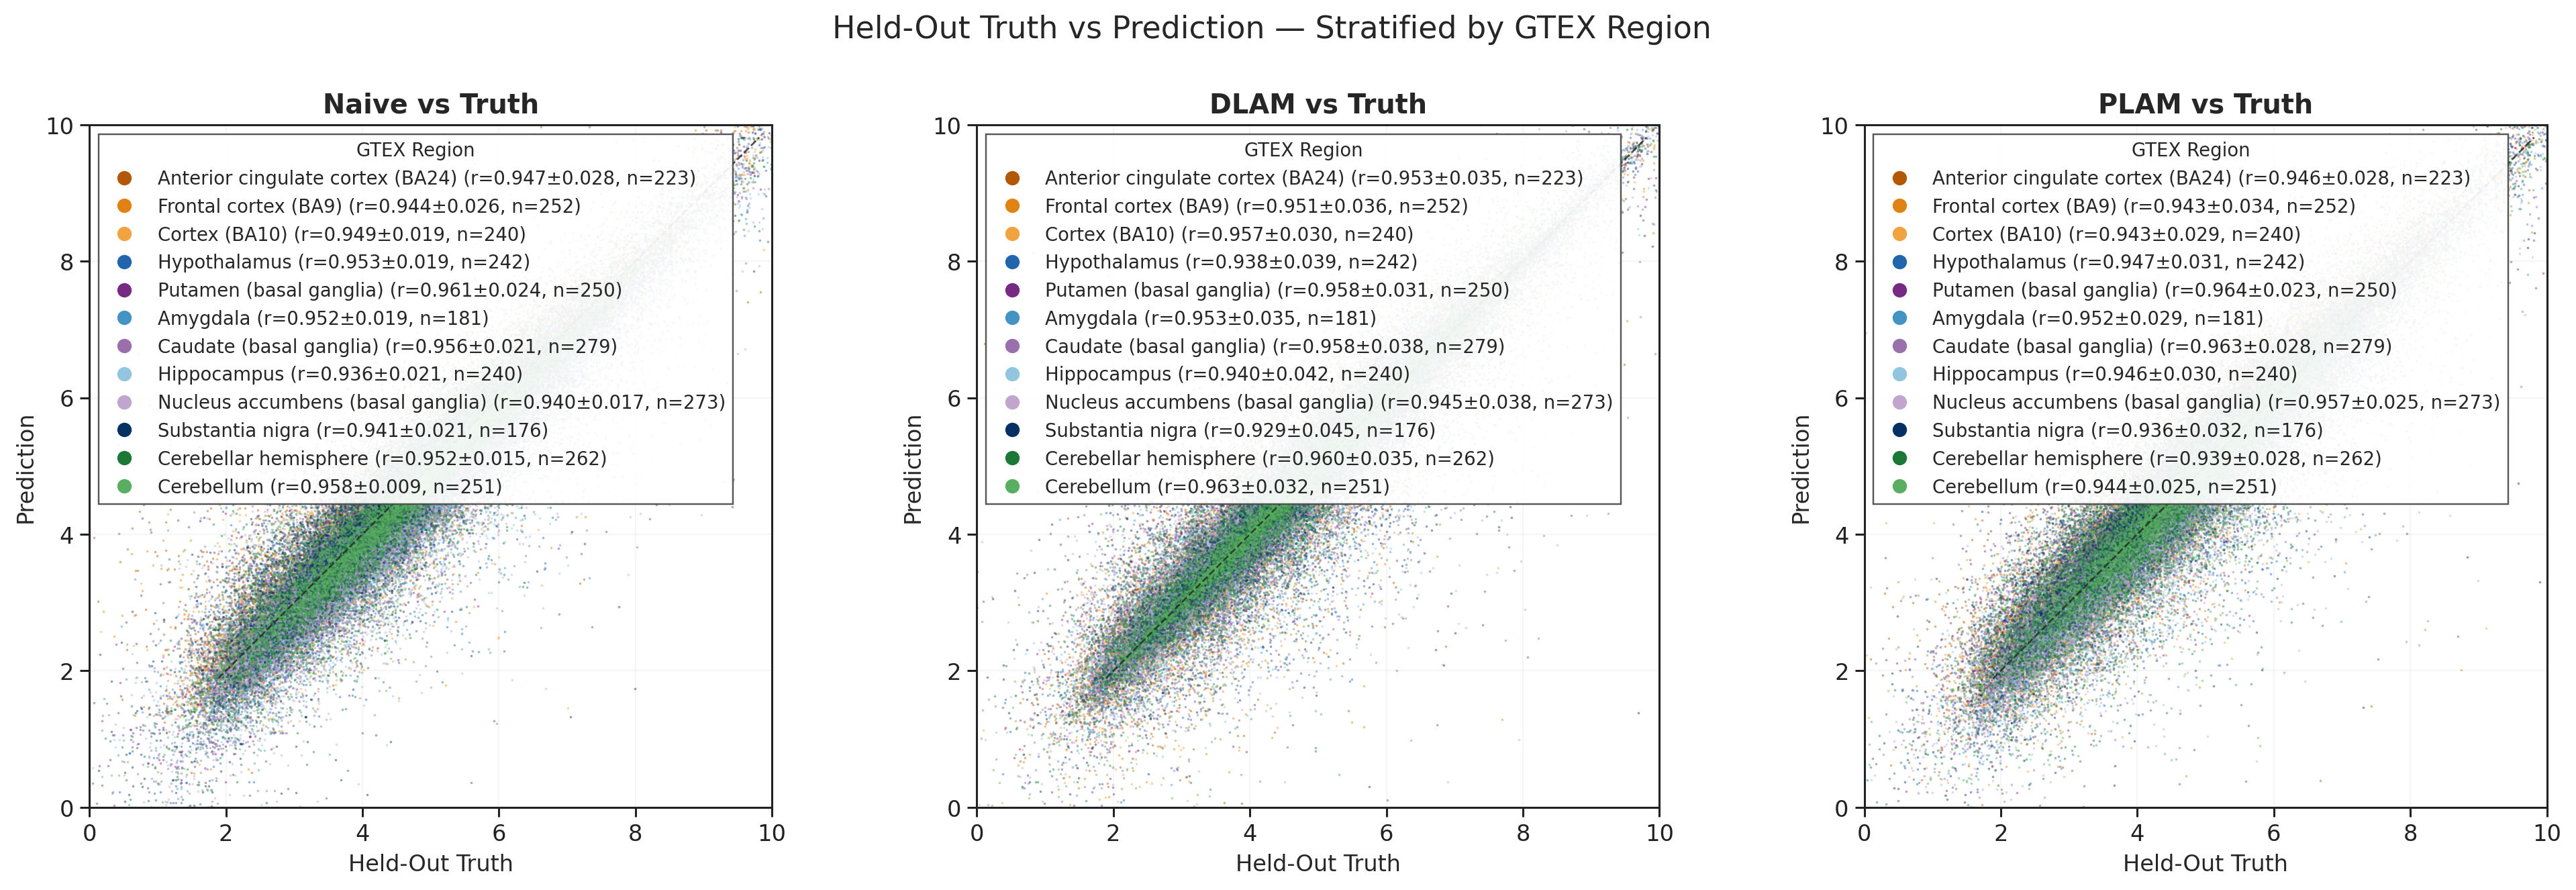

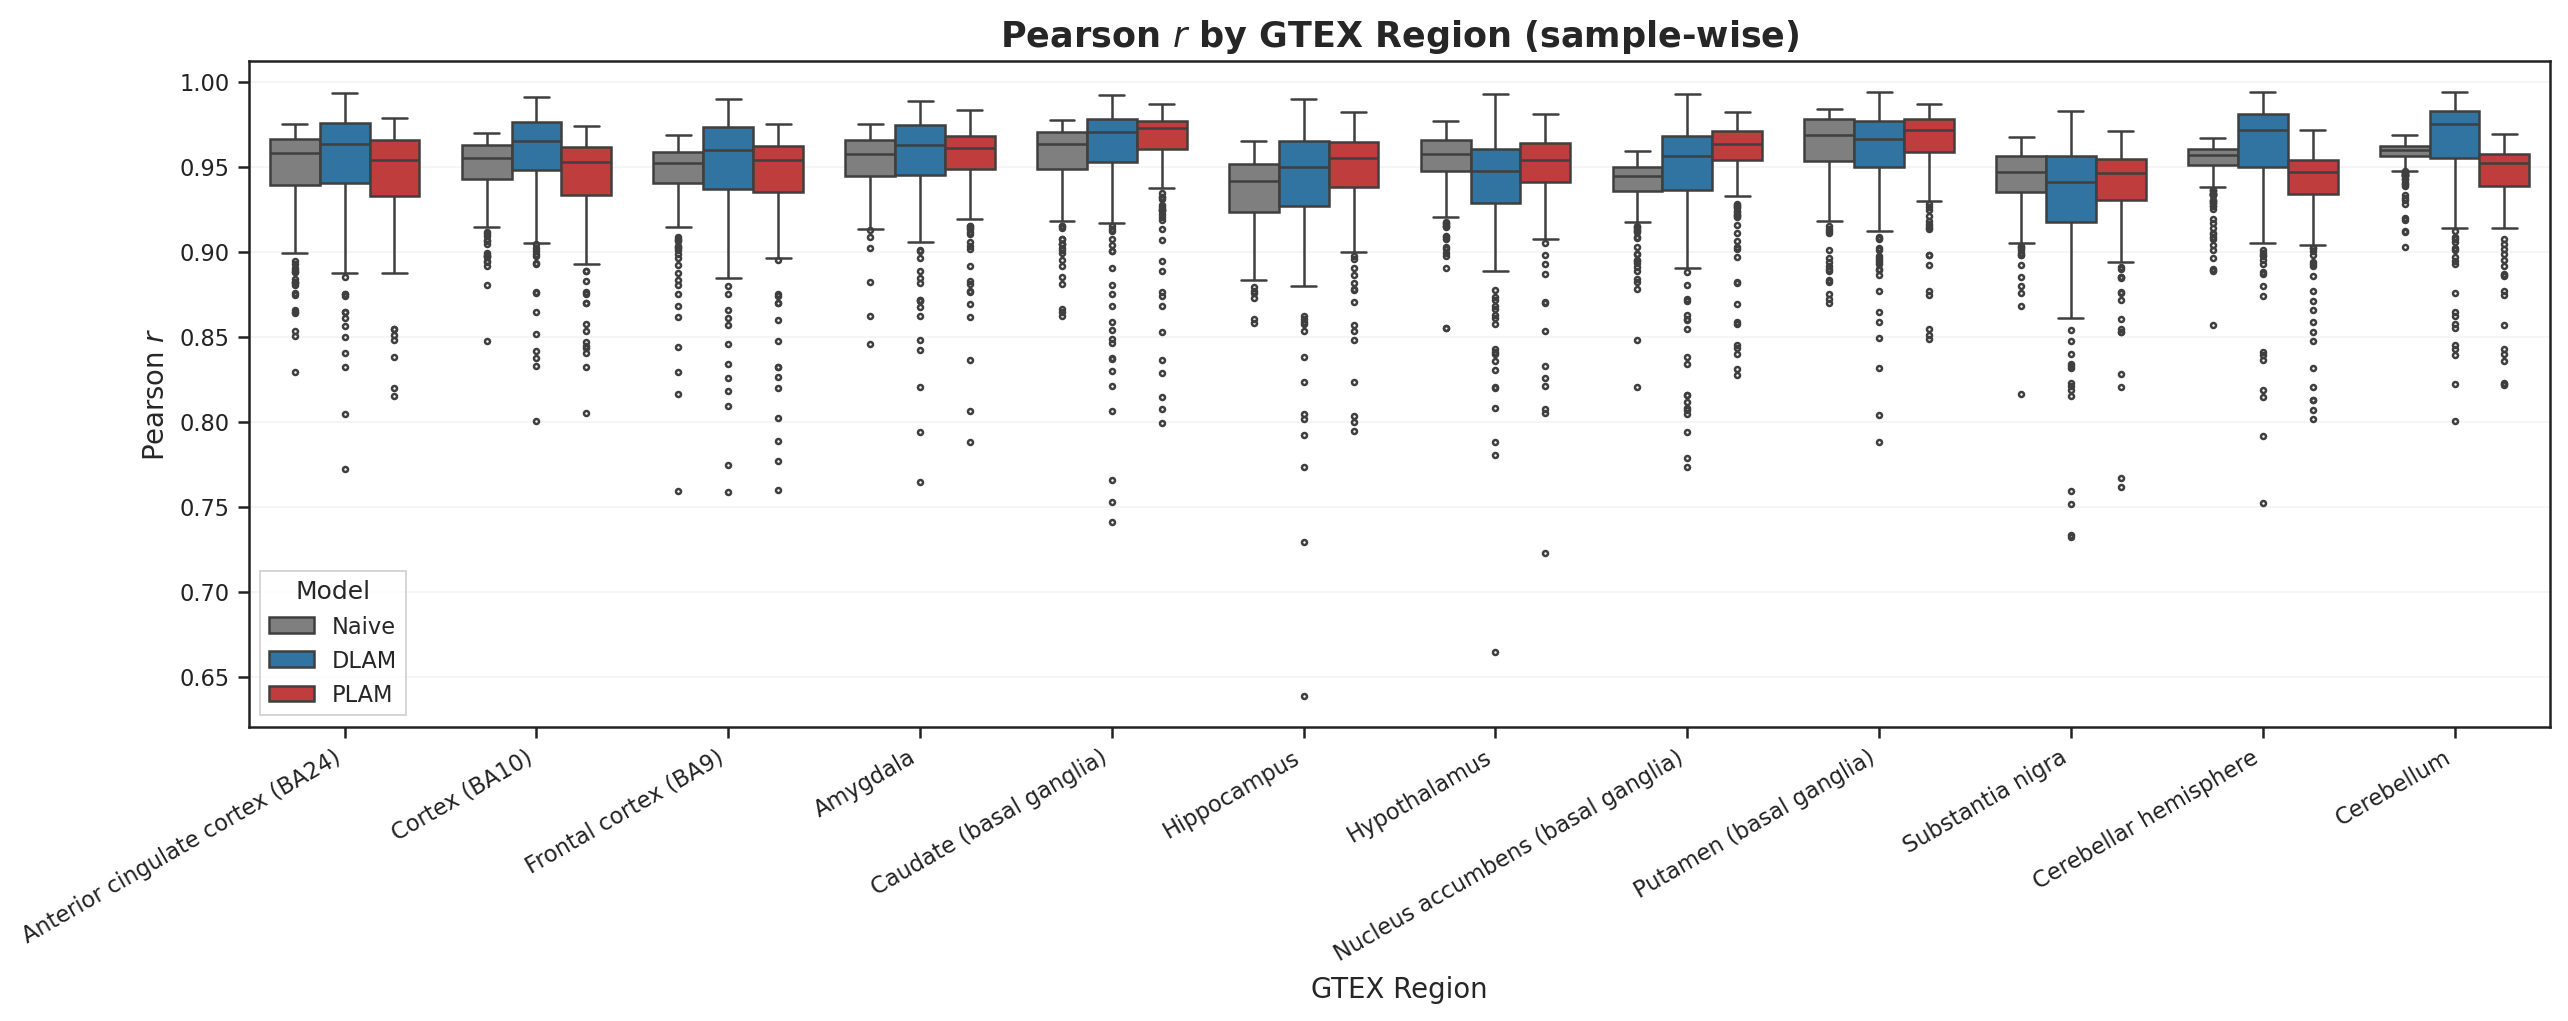

In [7]:
region_metrics, region_summary = compute_prediction_metrics(
    strat_view, unit='sample', stratify_by='gtex_region',
    metrics=TABLE_METRICS, n_jobs=N_JOBS,
)

fig, axes, _ = plot_stratified_scatter(
    strat_view, stratify_by='gtex_region',
    default_metric=DEFAULT_METRIC,
    max_points_per_model=SCATTER_MAX_POINTS_PER_MODEL,
    balanced_sampling=SCATTER_BALANCED_SAMPLING,
    metric_summary=region_summary,
)

fig, ax = plot_stratified_distribution(
    region_metrics, stratify_by='gtex_region',
    metric=DEFAULT_METRIC, kind=DISTRIBUTION_KIND,
)

region_table = format_stratified_metric_table(
    region_metrics, stratify_by='gtex_region', metrics=TABLE_METRICS,
)
display(region_table)


## DLAM Gene-Highlighted Region Fan

One figure per GTEx region for a single model. Points are flattened subject-sample by gene values in the selected gene list. A shared set of highlighted genes is colored consistently across all regions, while the remaining genes are shown as a faint background.


In [16]:
# Region gene fan toggles -- edit these before running this section.
REGION_FAN_MODEL = 'naive'
REGION_FAN_GENE_LIST_PATH = 'richiardi2015' # 'allgenes_stable_r0.8'  # e.g. richiardi2015 | allgenes_stable_r0.8
REGION_FAN_TOP_N_GENES = 10
REGION_FAN_SELECTION = 'top'          # top | bottom | list_order
REGION_FAN_RANK_MODEL = 'dlam'
REGION_FAN_RANK_METRIC = 'pearson_r'
REGION_FAN_HIGHLIGHT_GENES = None     # None = use ranked top-N; or explicit list of genes
REGION_FAN_REGIONS = None             # None = all regions in canonical display order; or list display/raw names
REGION_FAN_POINT_SIZE_BACKGROUND = 8.0
REGION_FAN_POINT_SIZE_HIGHLIGHT = 28.0
REGION_FAN_ALPHA_BACKGROUND = 0.08
REGION_FAN_ALPHA_HIGHLIGHT = 0.88
REGION_FAN_FIGSIZE = (8.8, 7.2)
REGION_FAN_DPI = 230
REGION_FAN_RANDOM_SEED = 42
REGION_FAN_AXIS_LIMITS = (0.0, 10.0)
REGION_FAN_AXIS_QUANTILES = None  # used only when REGION_FAN_AXIS_LIMITS is None
REGION_FAN_SHOW_FIT_LINE = True
REGION_FAN_SHOW_IDENTITY_LINE = False
REGION_FAN_FIT_LINEWIDTH = 2.2
REGION_FAN_FONT_SIZES = dict(title=20, label=18, tick=14, annotation=14, legend=16, legend_title=17, suptitle=22)


In [17]:
# Compute one shared gene ranking so every region highlights the same genes.
_region_gene_panel = make_prediction_eval_view(
    truth_df=truth_df,
    pred_dfs=pred_dfs,
    eval_gene_list_path=REGION_FAN_GENE_LIST_PATH,
    models=[REGION_FAN_RANK_MODEL],
    **VIEW_SUBSET,
)
_region_gene_metrics, _ = compute_prediction_metrics(
    _region_gene_panel,
    unit='gene',
    metrics=[REGION_FAN_RANK_METRIC],
    n_jobs=N_JOBS,
)
sublist_rank_lookup = dict(
    zip(_region_gene_metrics['gene'].astype(str), _region_gene_metrics[REGION_FAN_RANK_METRIC].astype(float))
)
_rank_ascending = REGION_FAN_SELECTION == 'bottom'
if REGION_FAN_HIGHLIGHT_GENES is None:
    REGION_FAN_SELECTED_GENES = (
        _region_gene_metrics.sort_values(REGION_FAN_RANK_METRIC, ascending=_rank_ascending)
        ['gene'].astype(str).head(REGION_FAN_TOP_N_GENES).tolist()
    )
else:
    REGION_FAN_SELECTED_GENES = [str(g) for g in REGION_FAN_HIGHLIGHT_GENES]
print('selected genes:', REGION_FAN_SELECTED_GENES)


selected genes: ['FZD7', 'SLC39A12', 'KRT31', 'LRRC38', 'GNA14', 'SHISA9', 'NECAB2', 'SYT2', 'KCNC1', 'CDR2L']


In [18]:
def _region_fan_raw_regions(view, requested=None):
    raw = view['truth_df']['gtex_region'].dropna().astype(str).unique().tolist()
    ordered = eval_population._gtex_region_group_order(view['truth_df'], raw)
    if requested is None:
        return ordered
    display_to_raw = {format_legend_label(r).lower(): r for r in raw}
    display_to_raw.update({pretty_gtex_label(r).lower(): r for r in raw})
    raw_lut = {r.lower(): r for r in raw}
    resolved = []
    for item in requested:
        key = str(item).lower()
        resolved.append(raw_lut.get(key, display_to_raw.get(key, str(item))))
    return [r for r in resolved if r in set(raw)]


def _region_palette(view):
    payloads = {}
    genes = list(view['genes'])
    for i, model in enumerate(ordered_models([REGION_FAN_MODEL])):
        payload, _ = eval_population._sample_scatter_payload_from_view(
            view['truth_df'], view['pred_dfs'][model], genes,
            max_points=None, random_seed=REGION_FAN_RANDOM_SEED + i,
        )
        payloads[model] = payload
    _, _order, palette = eval_population._global_scatter_color_spec(
        payloads,
        color_by='region',
        top_n=max(64, int(view['truth_df']['gtex_region'].nunique()) + 4),
        genes=None,
    )
    return palette


def _darken_color(color, factor=0.58):
    rgb = np.asarray(plt.matplotlib.colors.to_rgb(color), dtype=float)
    return tuple(np.clip(rgb * float(factor), 0.0, 1.0))


def _region_gene_flat_payload(region_view, model):
    genes = list(region_view['genes'])
    truth = region_view['truth_df']
    pred = region_view['pred_dfs'][model]
    x_mat = truth[genes].to_numpy(dtype=float)
    y_mat = pred[genes].to_numpy(dtype=float)
    n_samples, n_genes = x_mat.shape
    x = x_mat.ravel()
    y = y_mat.ravel()
    gene = np.tile(np.asarray(genes, dtype=object), n_samples)
    mask = np.isfinite(x) & np.isfinite(y)
    return {'x': x[mask], 'y': y[mask], 'gene': gene[mask]}, n_samples, n_genes


def _gene_palette(genes):
    payload = {'x': np.arange(len(genes)), 'y': np.arange(len(genes)), 'gene': np.asarray(genes, dtype=object)}
    _, order, palette = eval_population._global_scatter_color_spec(
        {'ranked': payload},
        color_by='gene',
        top_n=len(genes),
        genes=list(genes),
        gene_selection='list_order',
        highlight_genes=list(genes),
        random_seed=REGION_FAN_RANDOM_SEED,
    )
    return order, palette


def _fit_line_xy(x, y, lim_lo, lim_hi):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)
    if int(mask.sum()) < 2 or np.nanstd(x[mask]) <= 0:
        return None
    slope, intercept = np.polyfit(x[mask], y[mask], deg=1)
    xx = np.asarray([lim_lo, lim_hi], dtype=float)
    return xx, slope * xx + intercept


def _pearson_r(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)
    if int(mask.sum()) < 2:
        return np.nan
    return float(np.corrcoef(x[mask], y[mask])[0, 1])


def _r2_score(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)
    if int(mask.sum()) < 2:
        return np.nan
    denom = float(np.sum((x[mask] - np.mean(x[mask])) ** 2))
    if denom <= 0:
        return np.nan
    return float(1.0 - np.sum((x[mask] - y[mask]) ** 2) / denom)


def plot_region_gene_fan(region):
    region_view = make_prediction_eval_view(
        truth_df=truth_df,
        pred_dfs=pred_dfs,
        eval_gene_list_path=REGION_FAN_GENE_LIST_PATH,
        models=[REGION_FAN_MODEL],
        tissues=[region],
        **{k: v for k, v in VIEW_SUBSET.items() if k != 'tissues'},
    )
    payload, n_samples, n_genes = _region_gene_flat_payload(region_view, REGION_FAN_MODEL)
    selected = [g for g in REGION_FAN_SELECTED_GENES if g in set(region_view['genes'])]
    _, gene_palette = _gene_palette(selected)
    if REGION_FAN_AXIS_LIMITS is None:
        lim_lo, lim_hi = eval_population._axis_identity_limits([payload['x'], payload['y']], quantiles=REGION_FAN_AXIS_QUANTILES)
    else:
        lim_lo, lim_hi = [float(x) for x in REGION_FAN_AXIS_LIMITS]
    ticks = eval_population._nice_interval_ticks(lim_lo, lim_hi, n_ticks=6)
    fonts = REGION_FAN_FONT_SIZES
    roi_color = _REGION_FAN_REGION_PALETTE.get(region, '#4c78a8')
    roi_fit_color = _darken_color(roi_color)

    fig, ax = plt.subplots(figsize=REGION_FAN_FIGSIZE, dpi=REGION_FAN_DPI)
    selected_mask = np.isin(payload['gene'].astype(str), selected)
    ax.scatter(
        payload['x'][~selected_mask], payload['y'][~selected_mask],
        s=REGION_FAN_POINT_SIZE_BACKGROUND,
        alpha=REGION_FAN_ALPHA_BACKGROUND,
        color='#555555', edgecolors='none', rasterized=True,
        label='Other genes',
    )
    for gene in selected:
        m = payload['gene'].astype(str) == gene
        ax.scatter(
            payload['x'][m], payload['y'][m],
            s=REGION_FAN_POINT_SIZE_HIGHLIGHT,
            alpha=REGION_FAN_ALPHA_HIGHLIGHT,
            color=gene_palette.get(gene, '#4c78a8'),
            edgecolors='none', rasterized=True,
        )
    if REGION_FAN_SHOW_IDENTITY_LINE:
        ax.plot([lim_lo, lim_hi], [lim_lo, lim_hi], color='#252525', linestyle=':', linewidth=1.1, alpha=0.70)
    if REGION_FAN_SHOW_FIT_LINE:
        fit_xy = _fit_line_xy(payload['x'], payload['y'], lim_lo, lim_hi)
        if fit_xy is not None:
            ax.plot(fit_xy[0], fit_xy[1], color=roi_fit_color, linestyle='--', linewidth=REGION_FAN_FIT_LINEWIDTH, alpha=0.95)
    ax.set_xlim(lim_lo, lim_hi)
    ax.set_ylim(lim_lo, lim_hi)
    ax.set_aspect('equal', adjustable='box')
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)
    ax.tick_params(axis='both', labelsize=fonts['tick'])
    ax.set_xlabel('Held-Out Truth', fontsize=fonts['label'])
    ax.set_ylabel('Prediction', fontsize=fonts['label'])
    r_all = _pearson_r(payload['x'], payload['y'])
    r2_all = _r2_score(payload['x'], payload['y'])
    ax.text(
        0.04, 0.96,
        f"{model_label(REGION_FAN_MODEL)}\nr = {r_all:.3f}\nR² = {r2_all:.3f}\n{n_samples:,} samples × {n_genes:,} genes",
        transform=ax.transAxes, ha='left', va='top', fontsize=fonts['annotation'],
        bbox=dict(facecolor='white', edgecolor='#6b6b6b', alpha=0.92, boxstyle='round,pad=0.28'),
    )
    handles = []
    for gene in selected:
        m = payload['gene'].astype(str) == gene
        r_gene = _pearson_r(payload['x'][m], payload['y'][m])
        handles.append(plt.Line2D([0], [0], marker='o', linestyle='none',
                                  markerfacecolor=gene_palette.get(gene, '#4c78a8'),
                                  markeredgecolor='none', markersize=8,
                                  label=f'{gene} (r={r_gene:.2f})'))
    ax.legend(handles=handles, title=f'{REGION_FAN_GENE_LIST_PATH} genes',
              loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=True,
              fontsize=fonts['legend'], title_fontsize=fonts['legend_title'])
    ax.grid(True, alpha=0.16)
    ax.set_title(pretty_gtex_label(region), fontsize=fonts['title'])
    fig.suptitle(
        f"{model_label(REGION_FAN_MODEL)} gene-highlighted regional fan",
        fontsize=fonts['suptitle'], y=1.02,
    )
    fig.tight_layout()
    return fig, ax


regions: ['Anterior cingulate cortex (BA24)', 'Cortex (BA10)', 'Frontal cortex (BA9)', 'Amygdala', 'Caudate (basal ganglia)', 'Hippocampus', 'Hypothalamus', 'Nucleus accumbens (basal ganglia)', 'Putamen (basal ganglia)', 'Substantia nigra', 'Cerebellar hemisphere', 'Cerebellum']


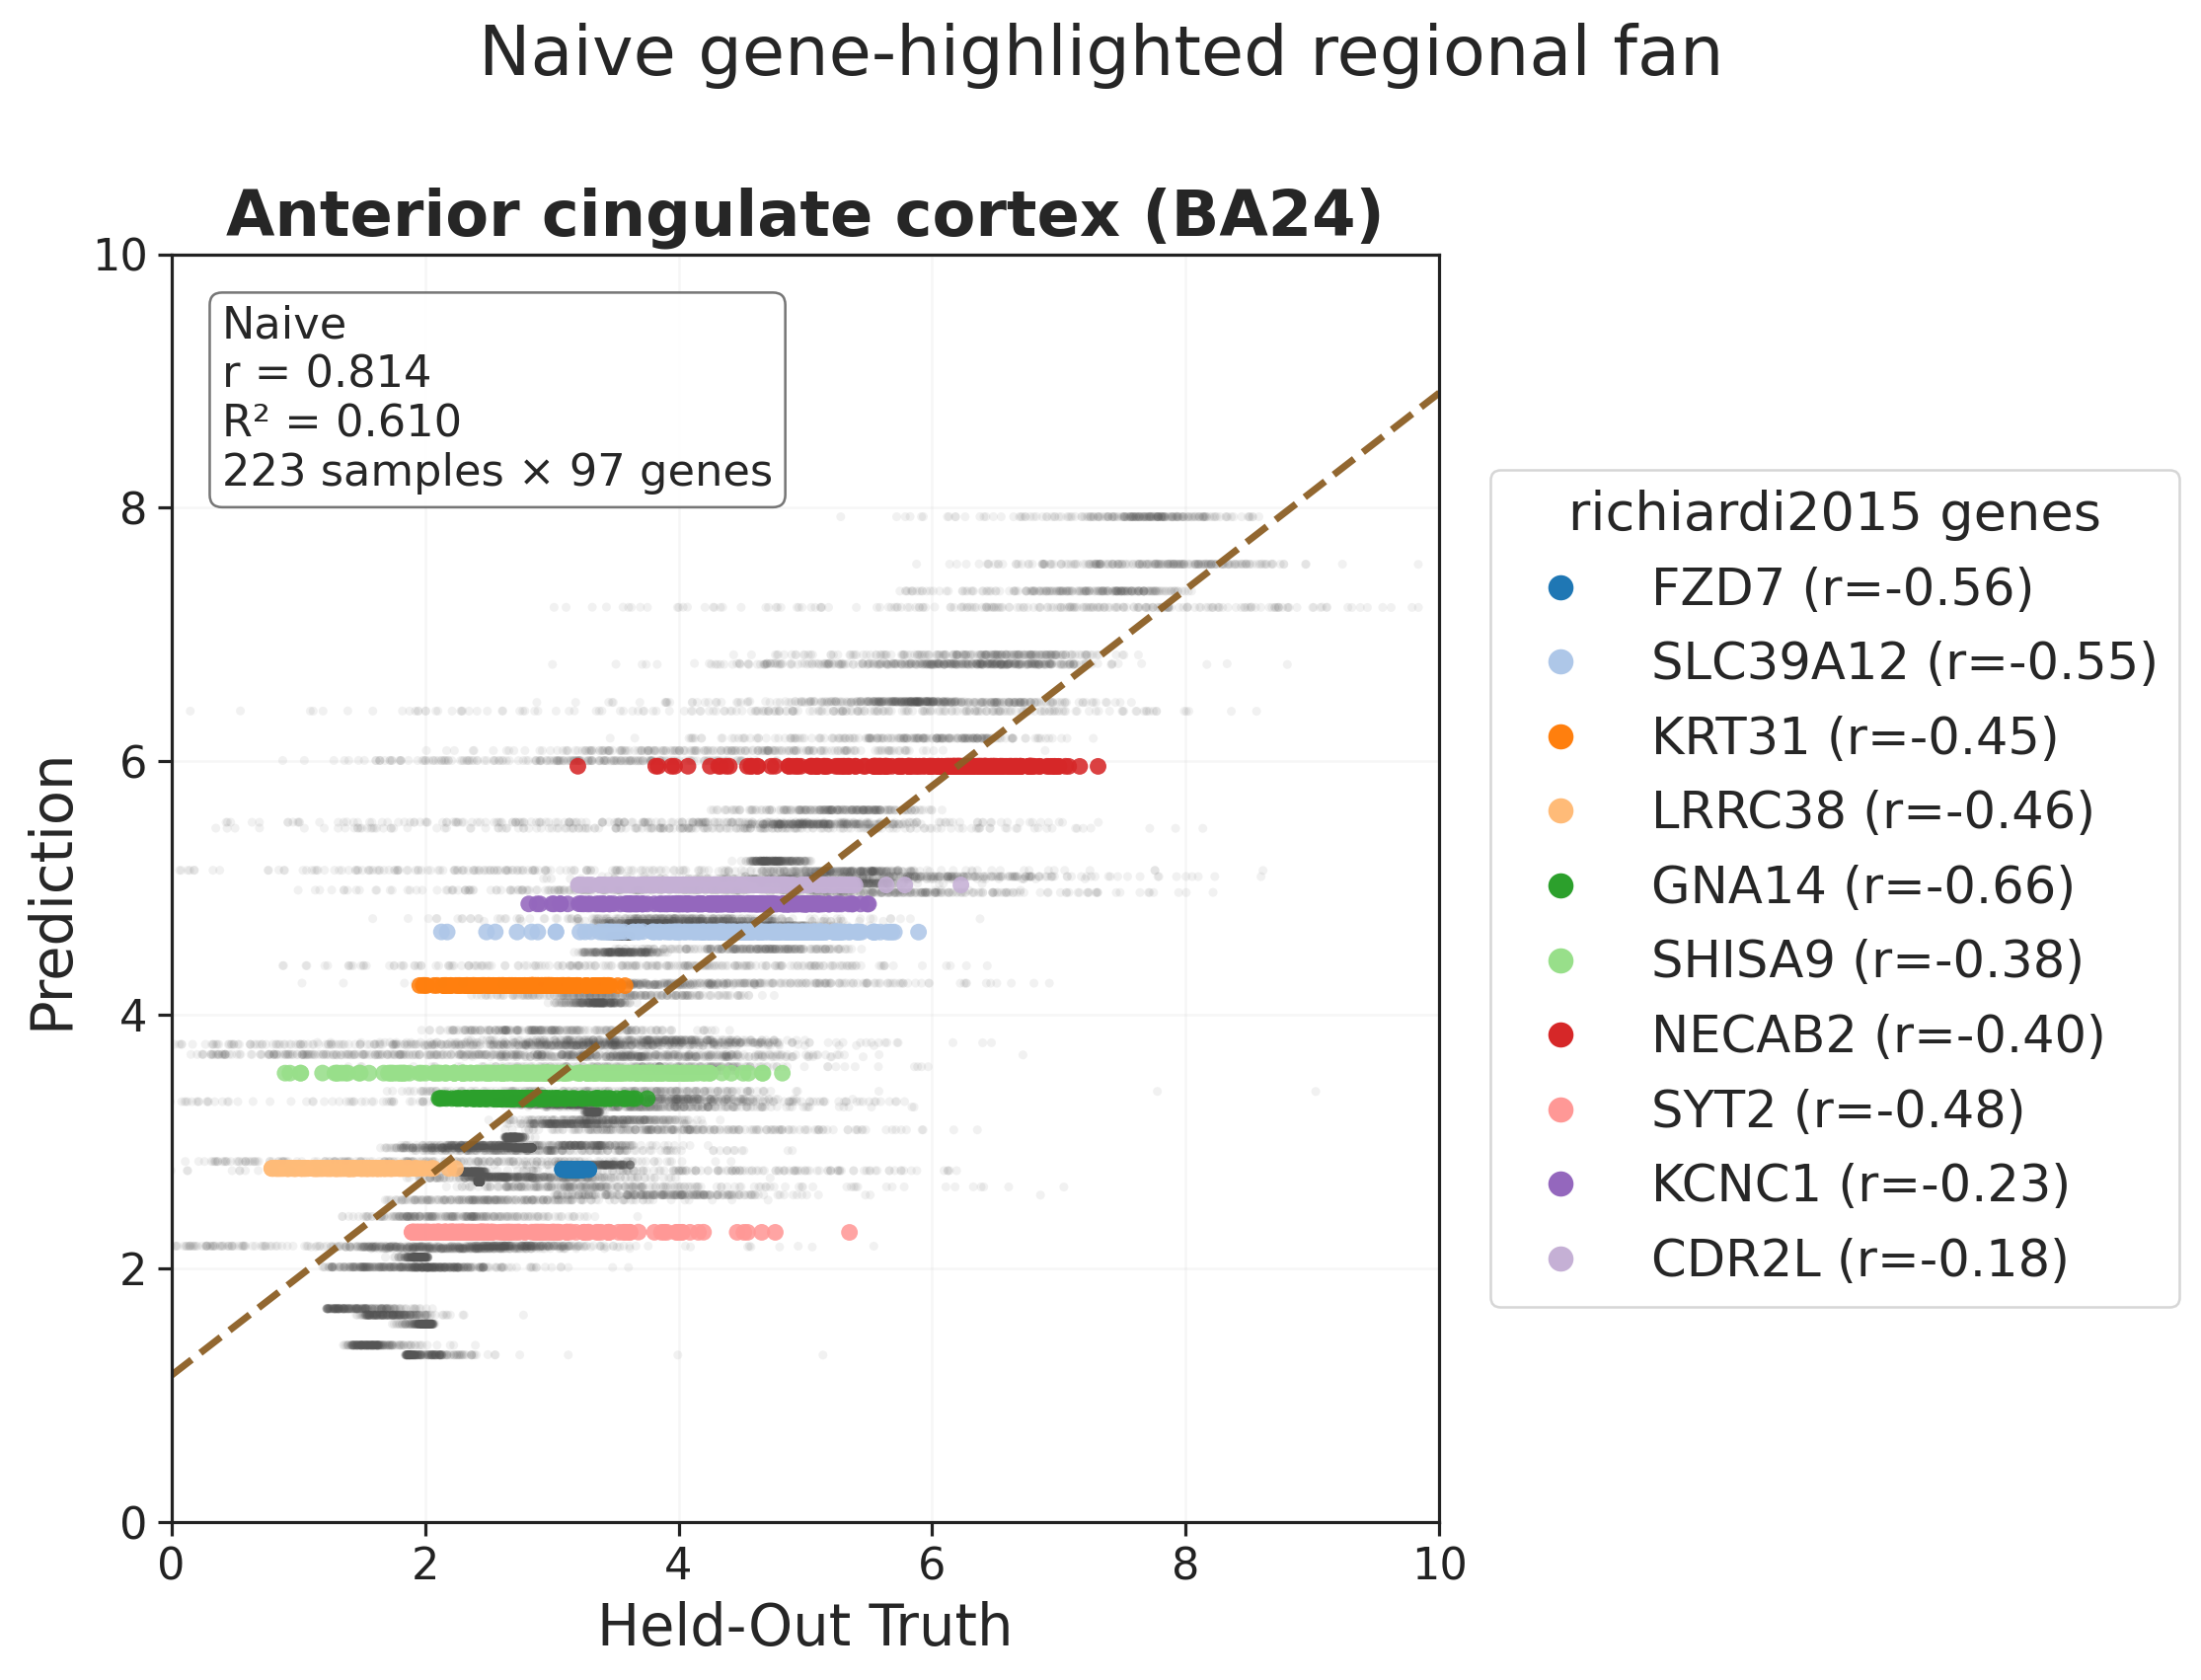

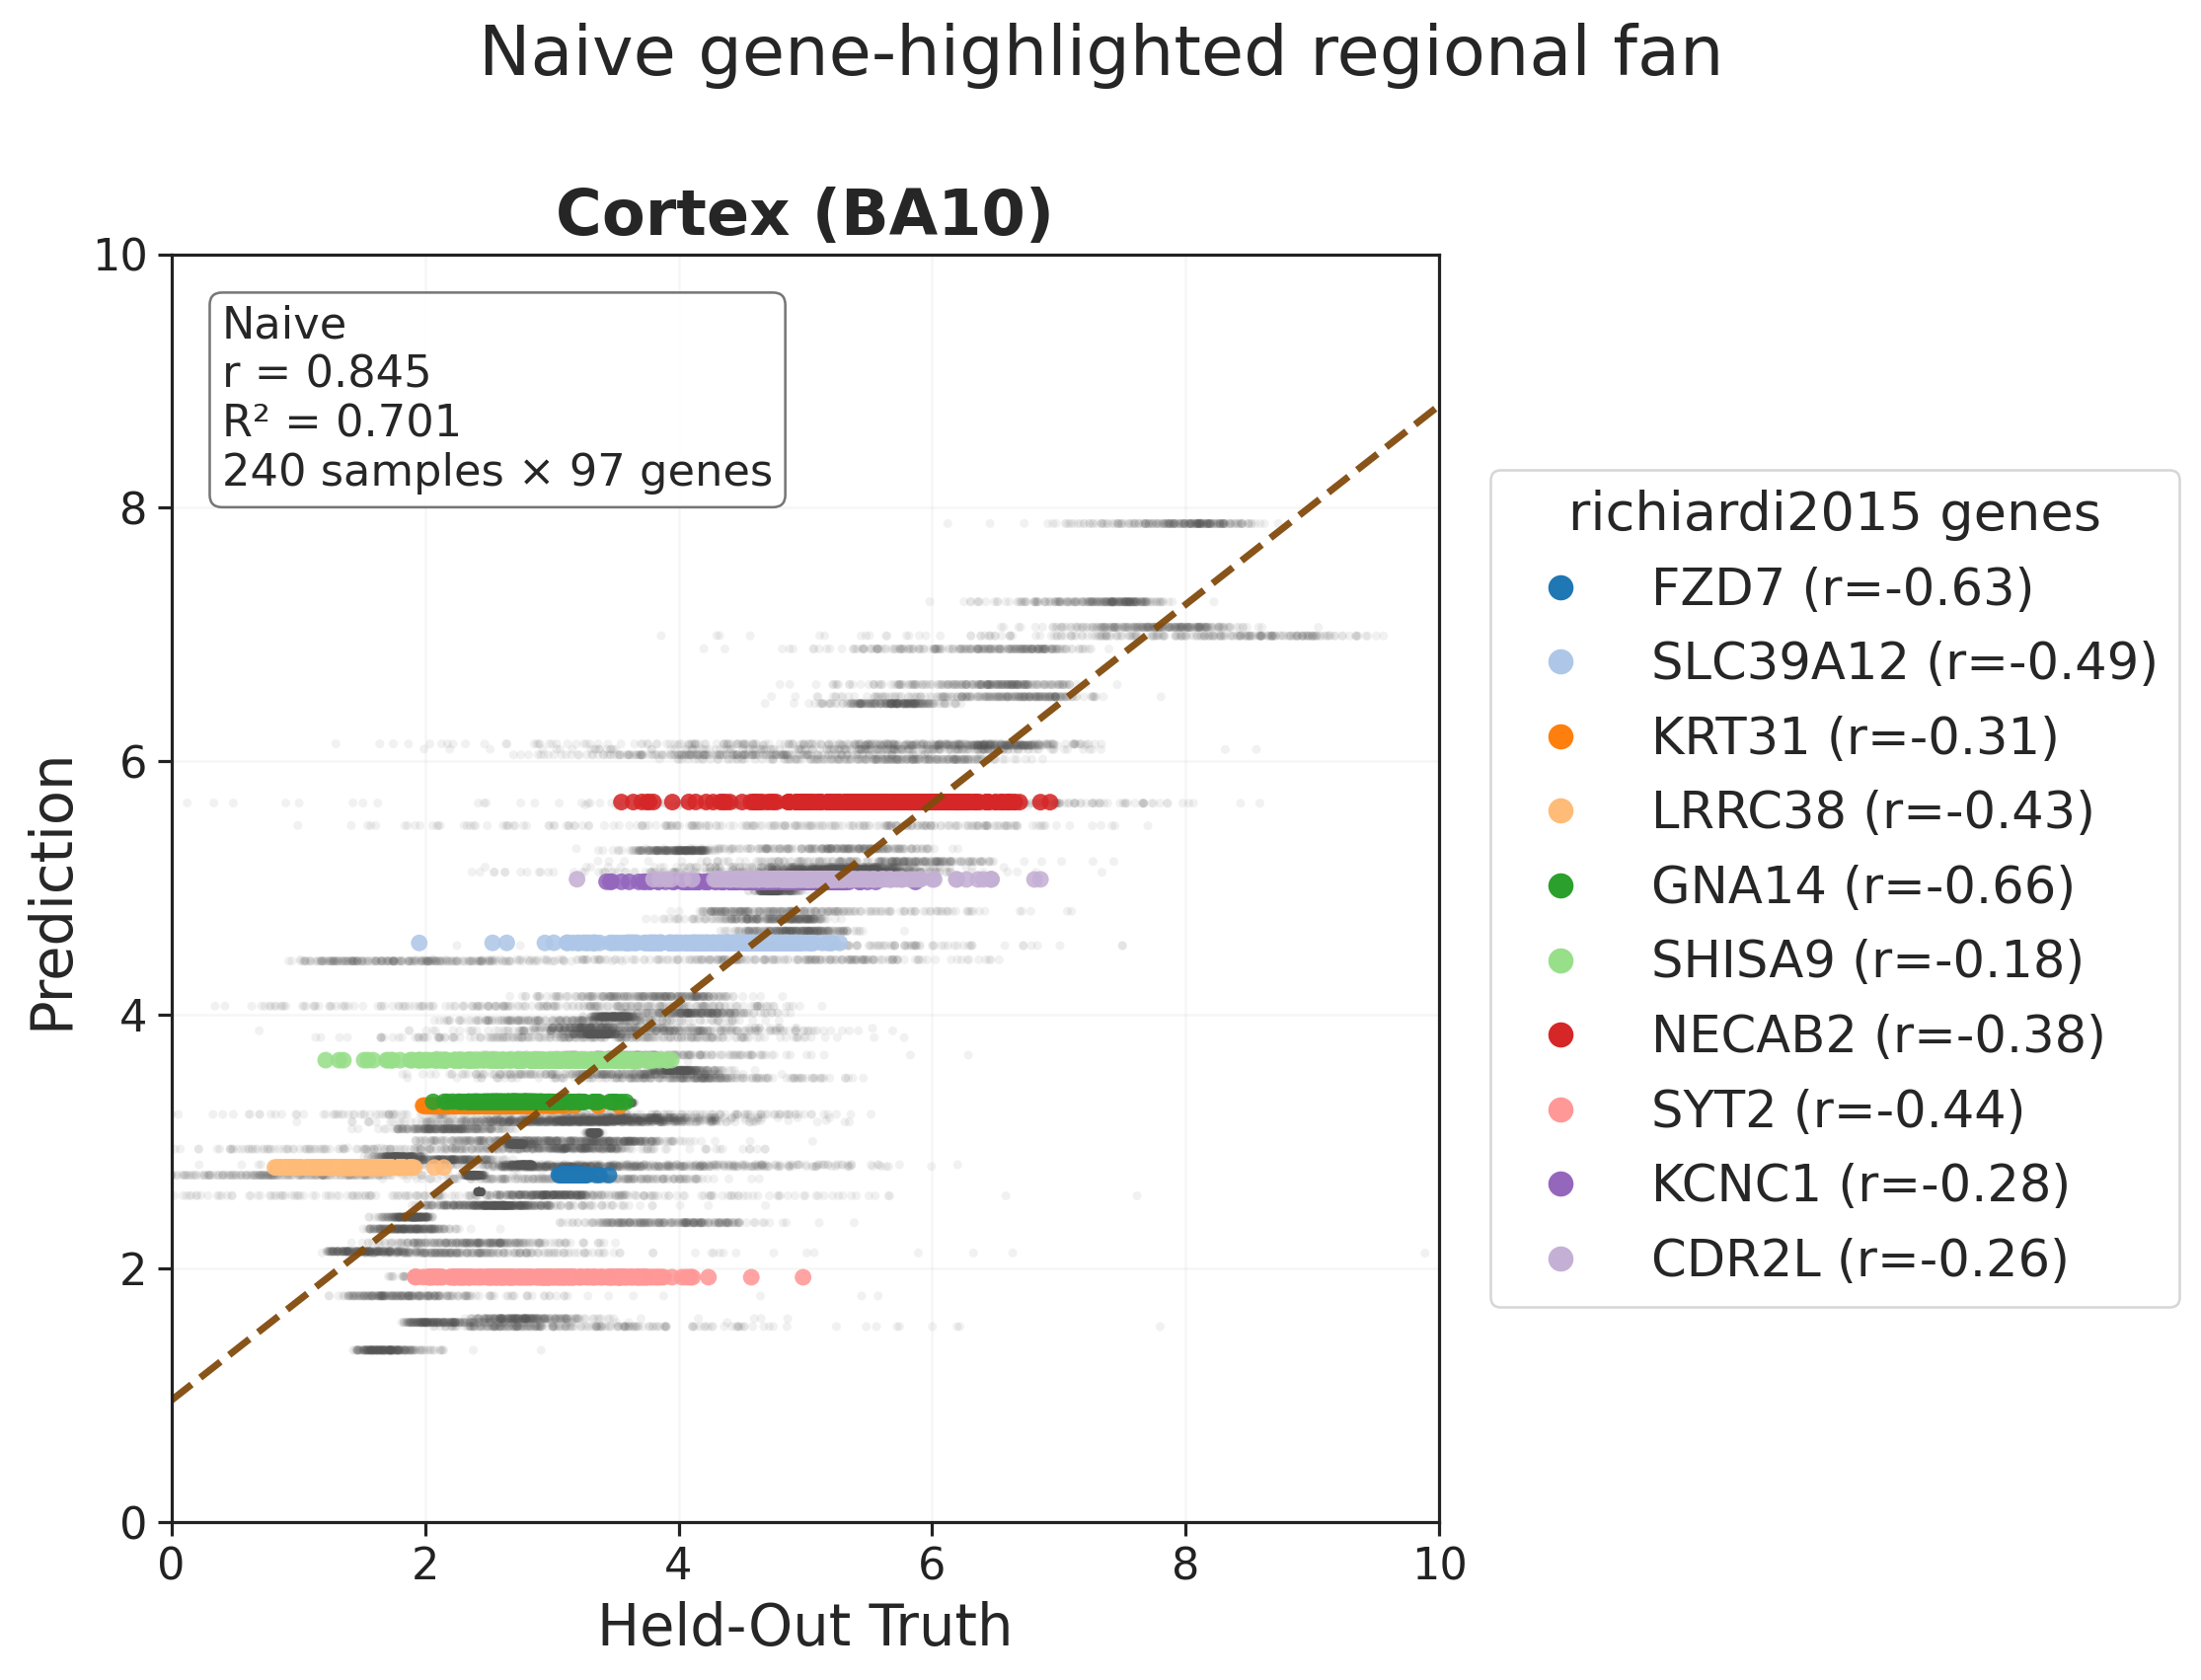

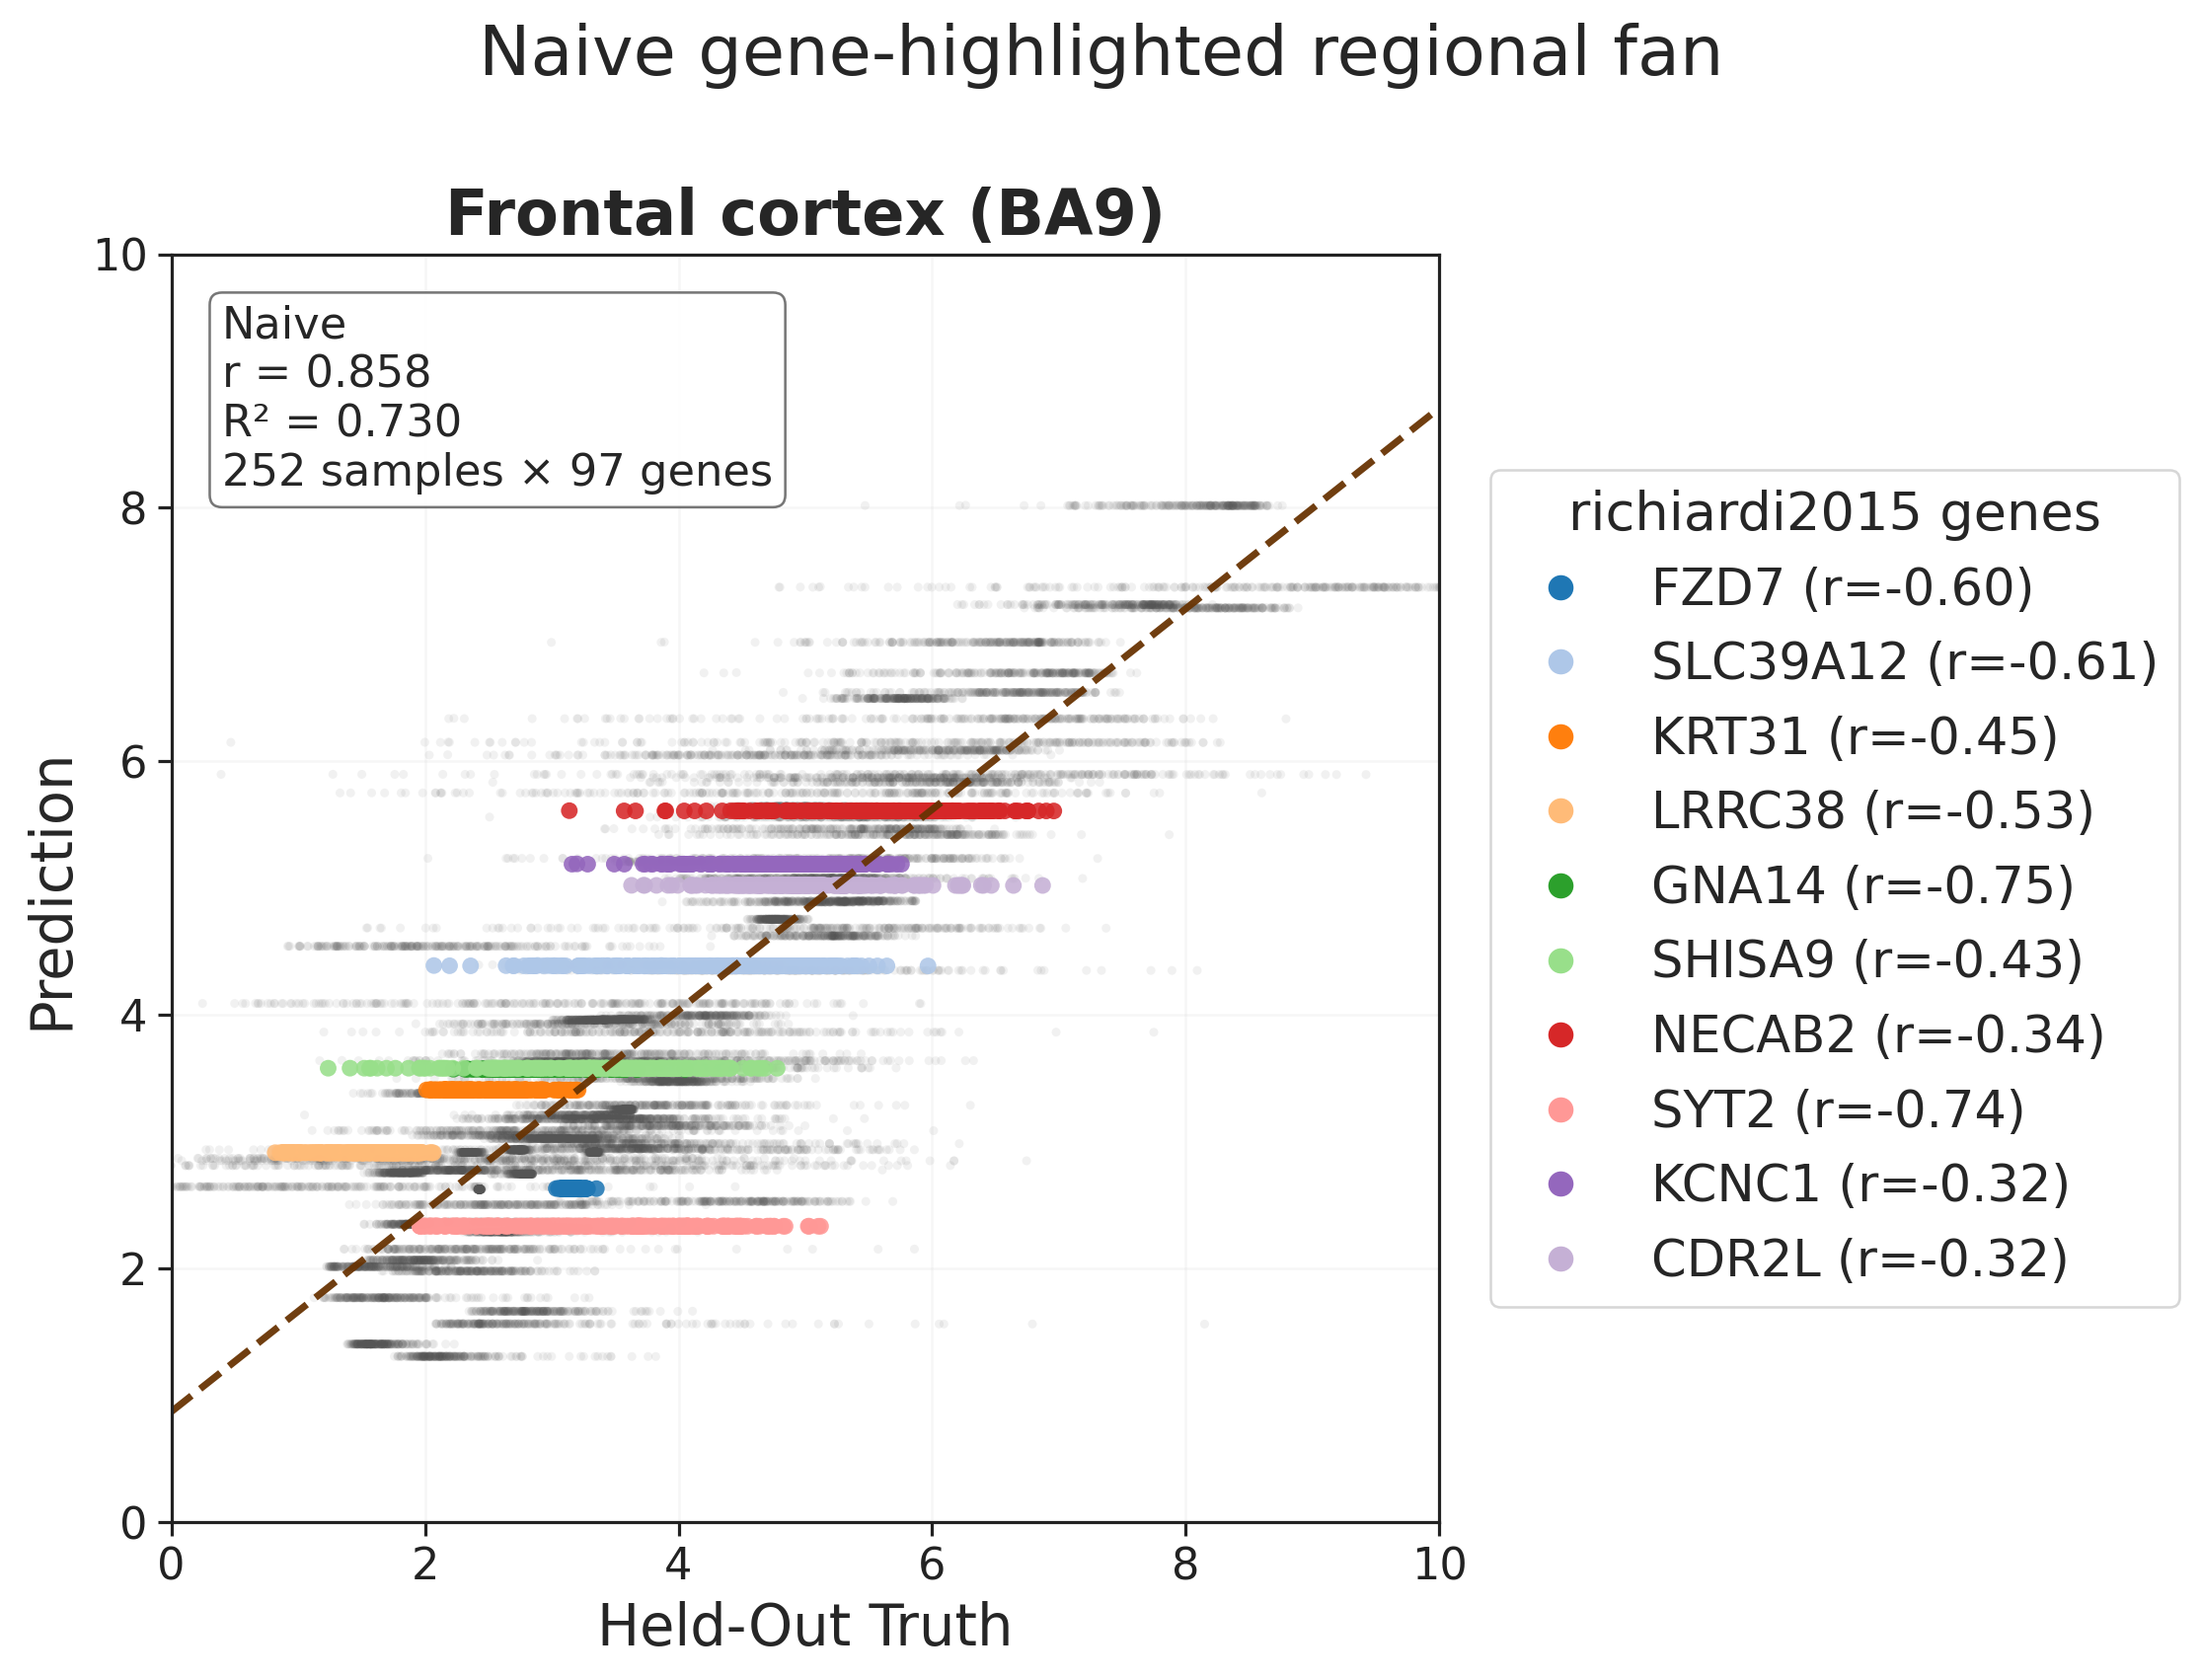

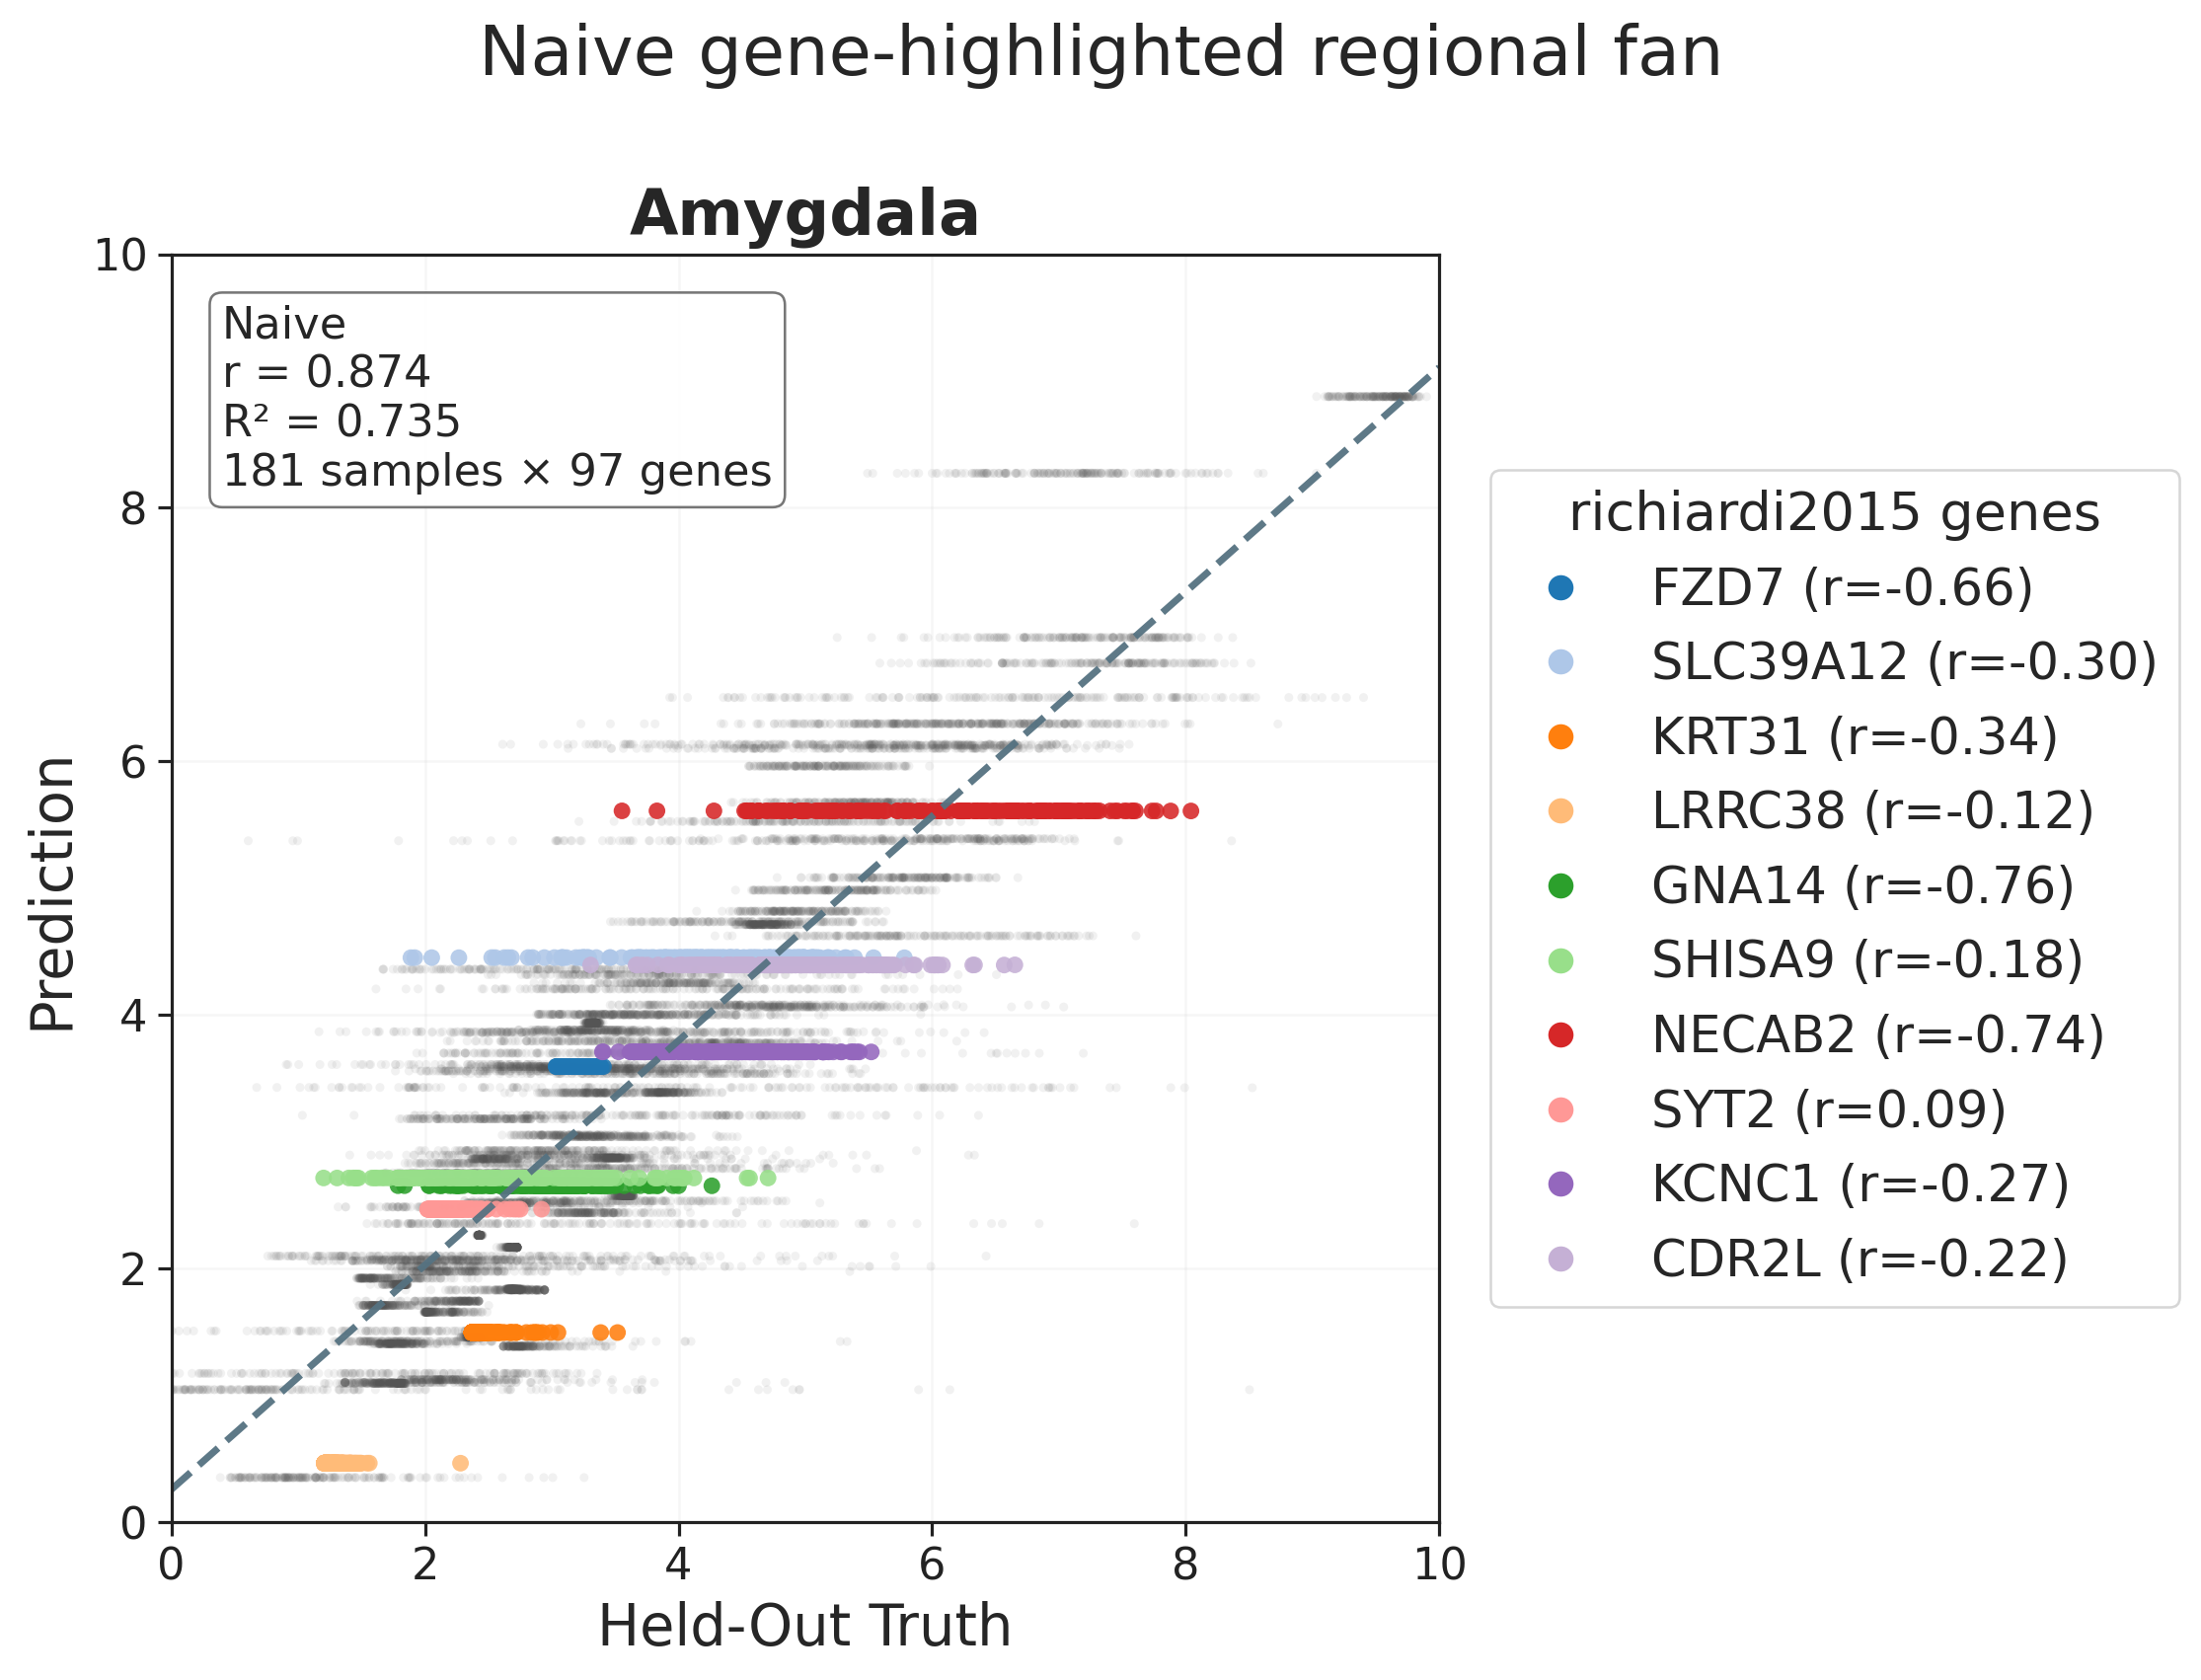

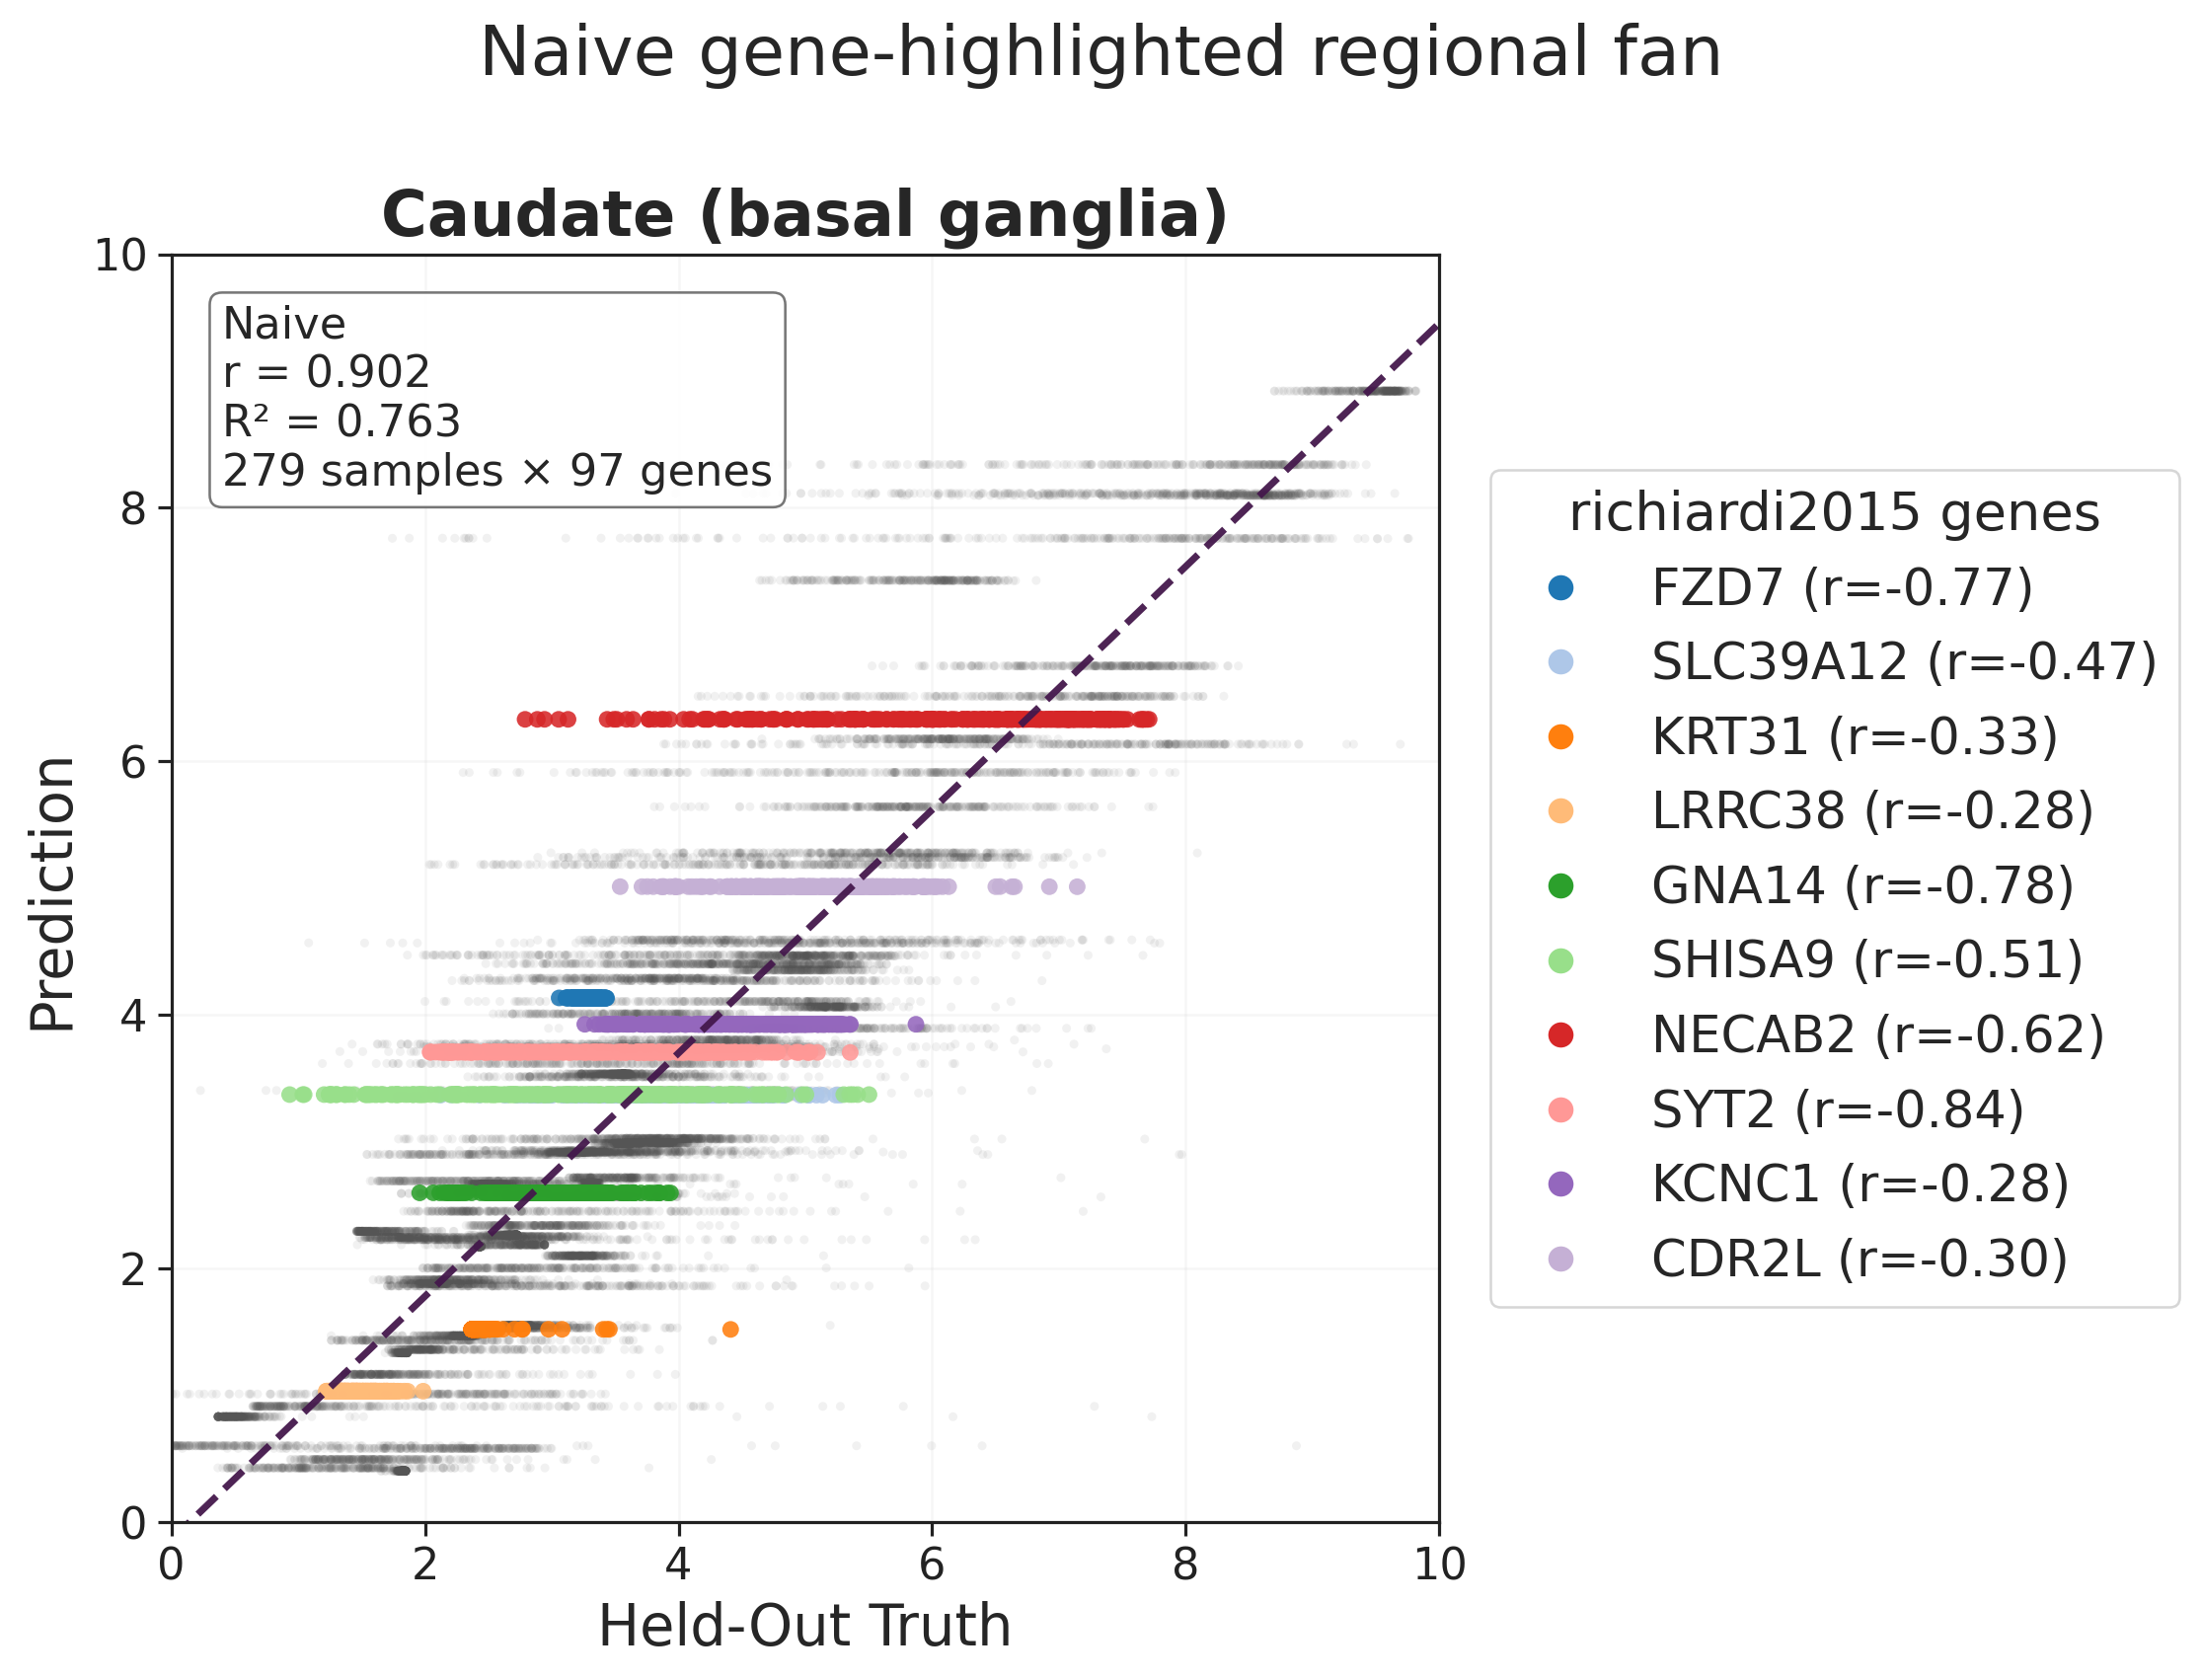

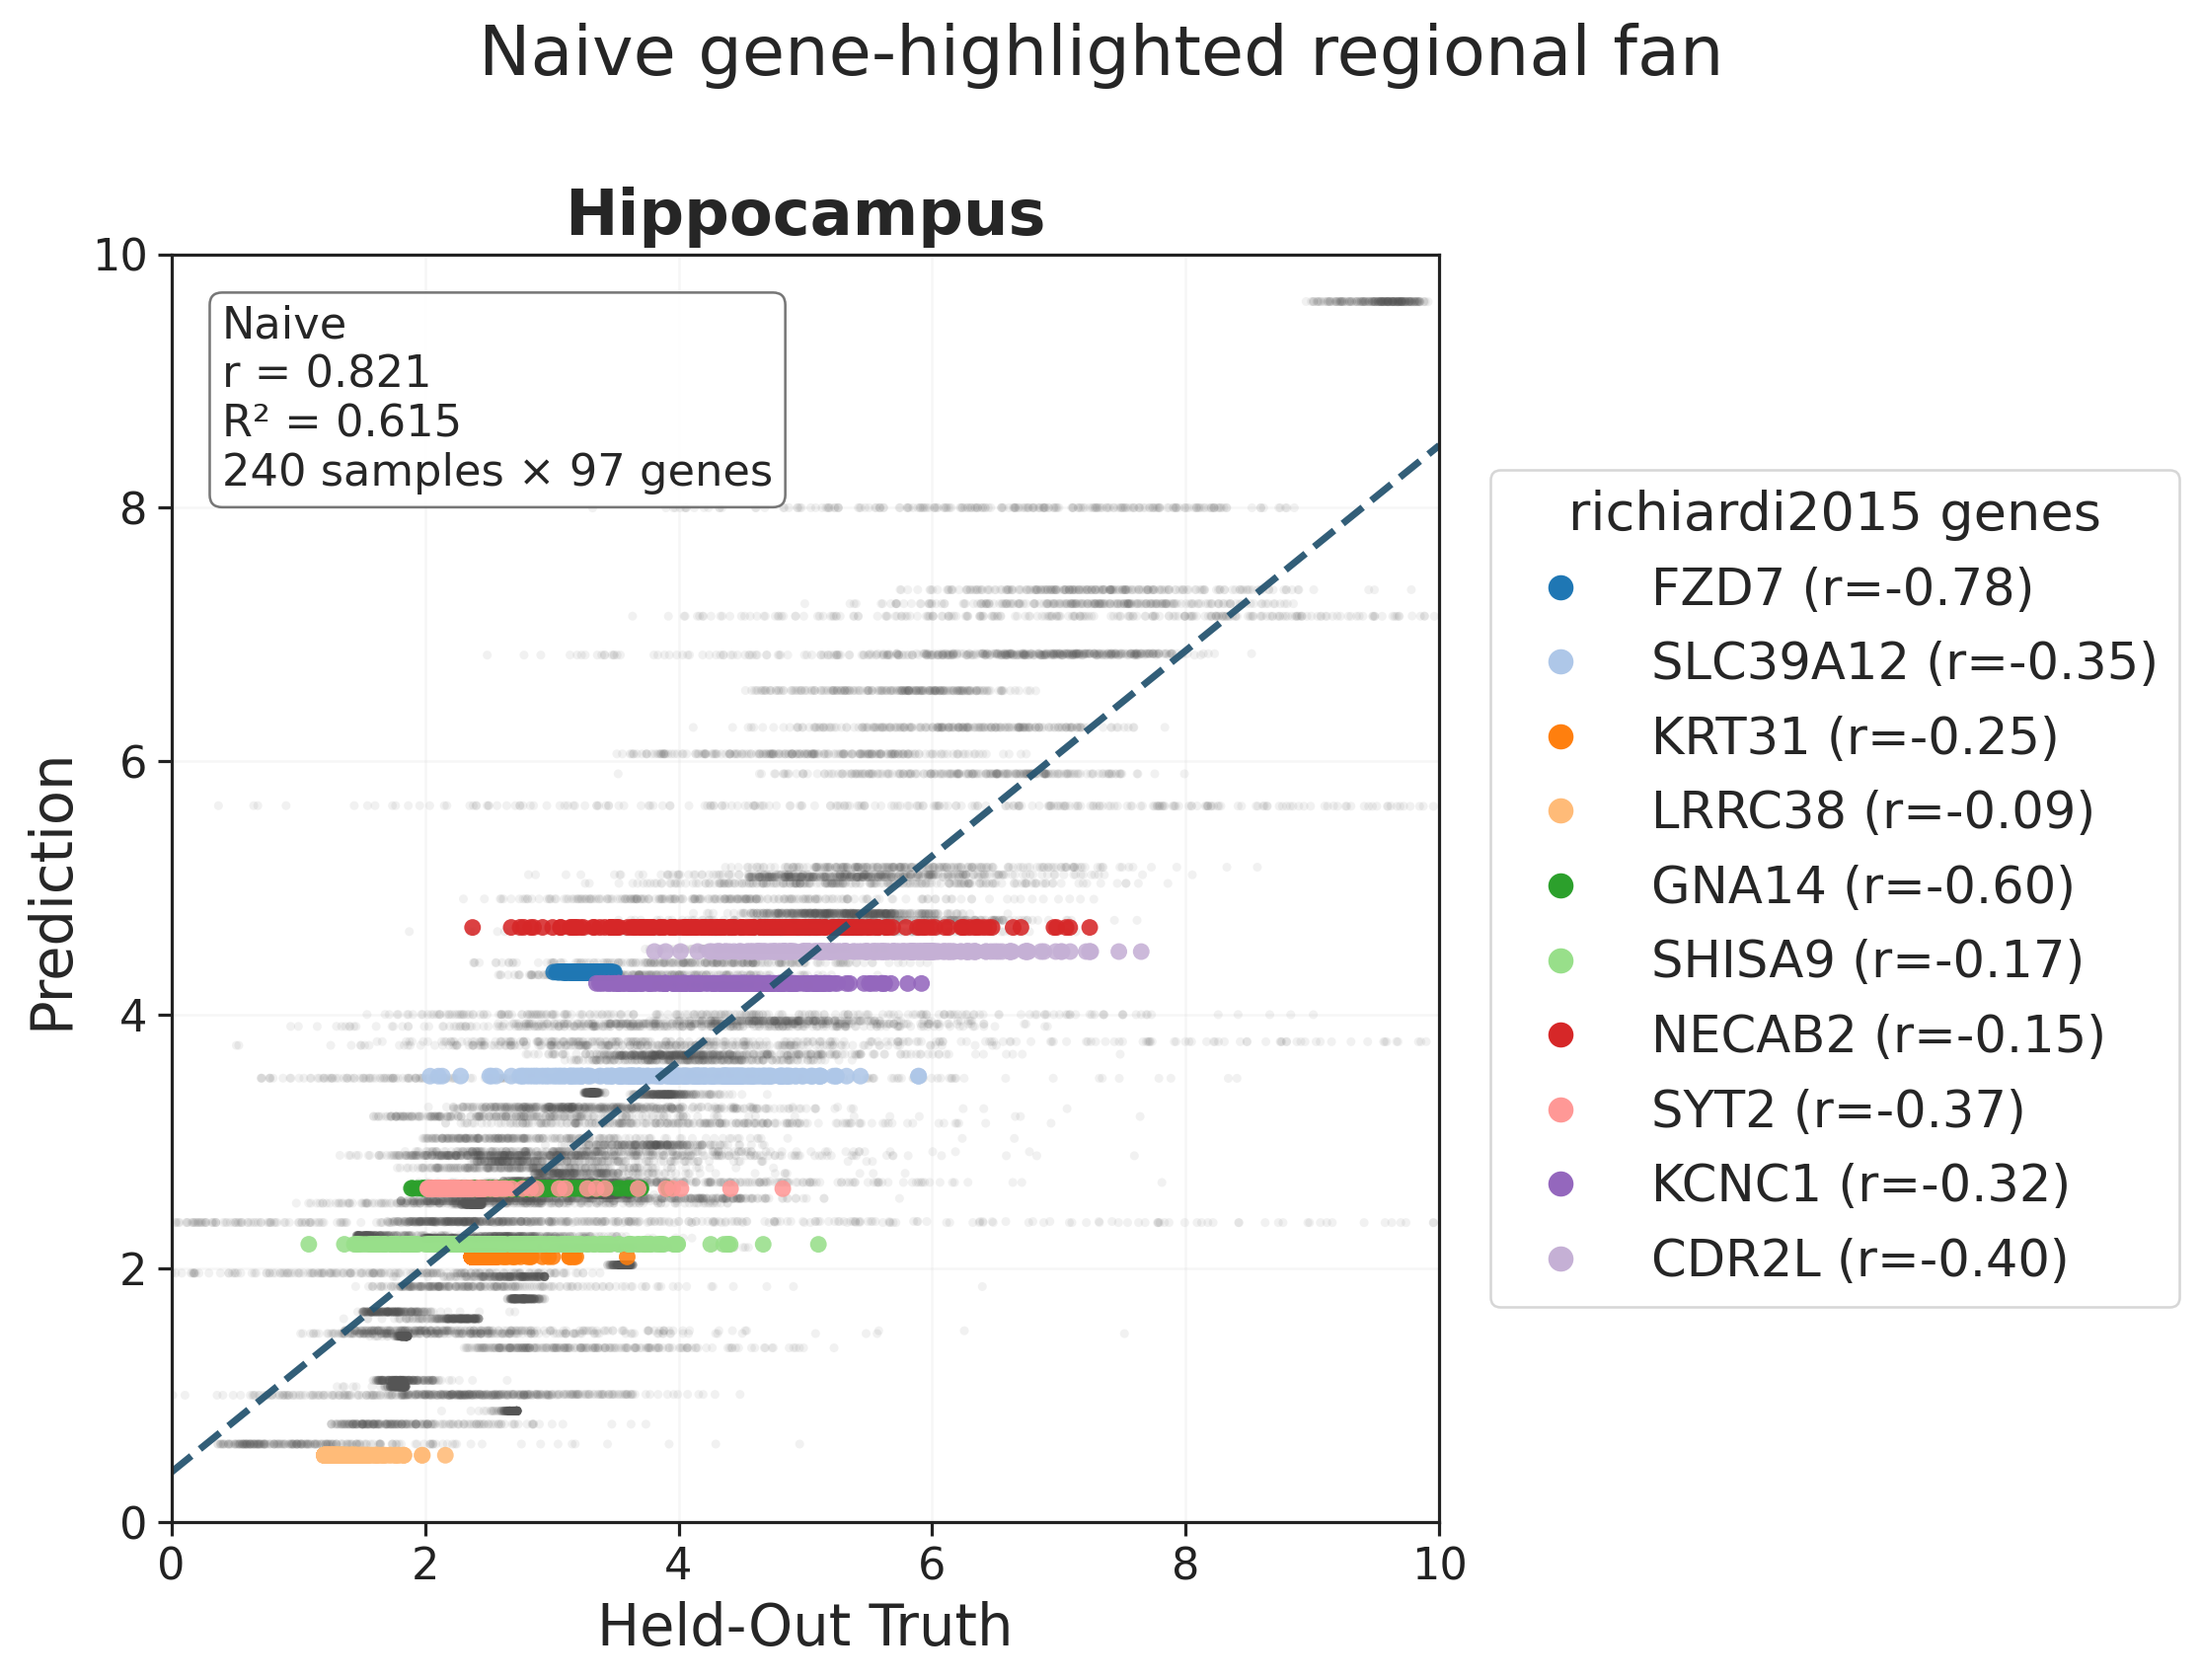

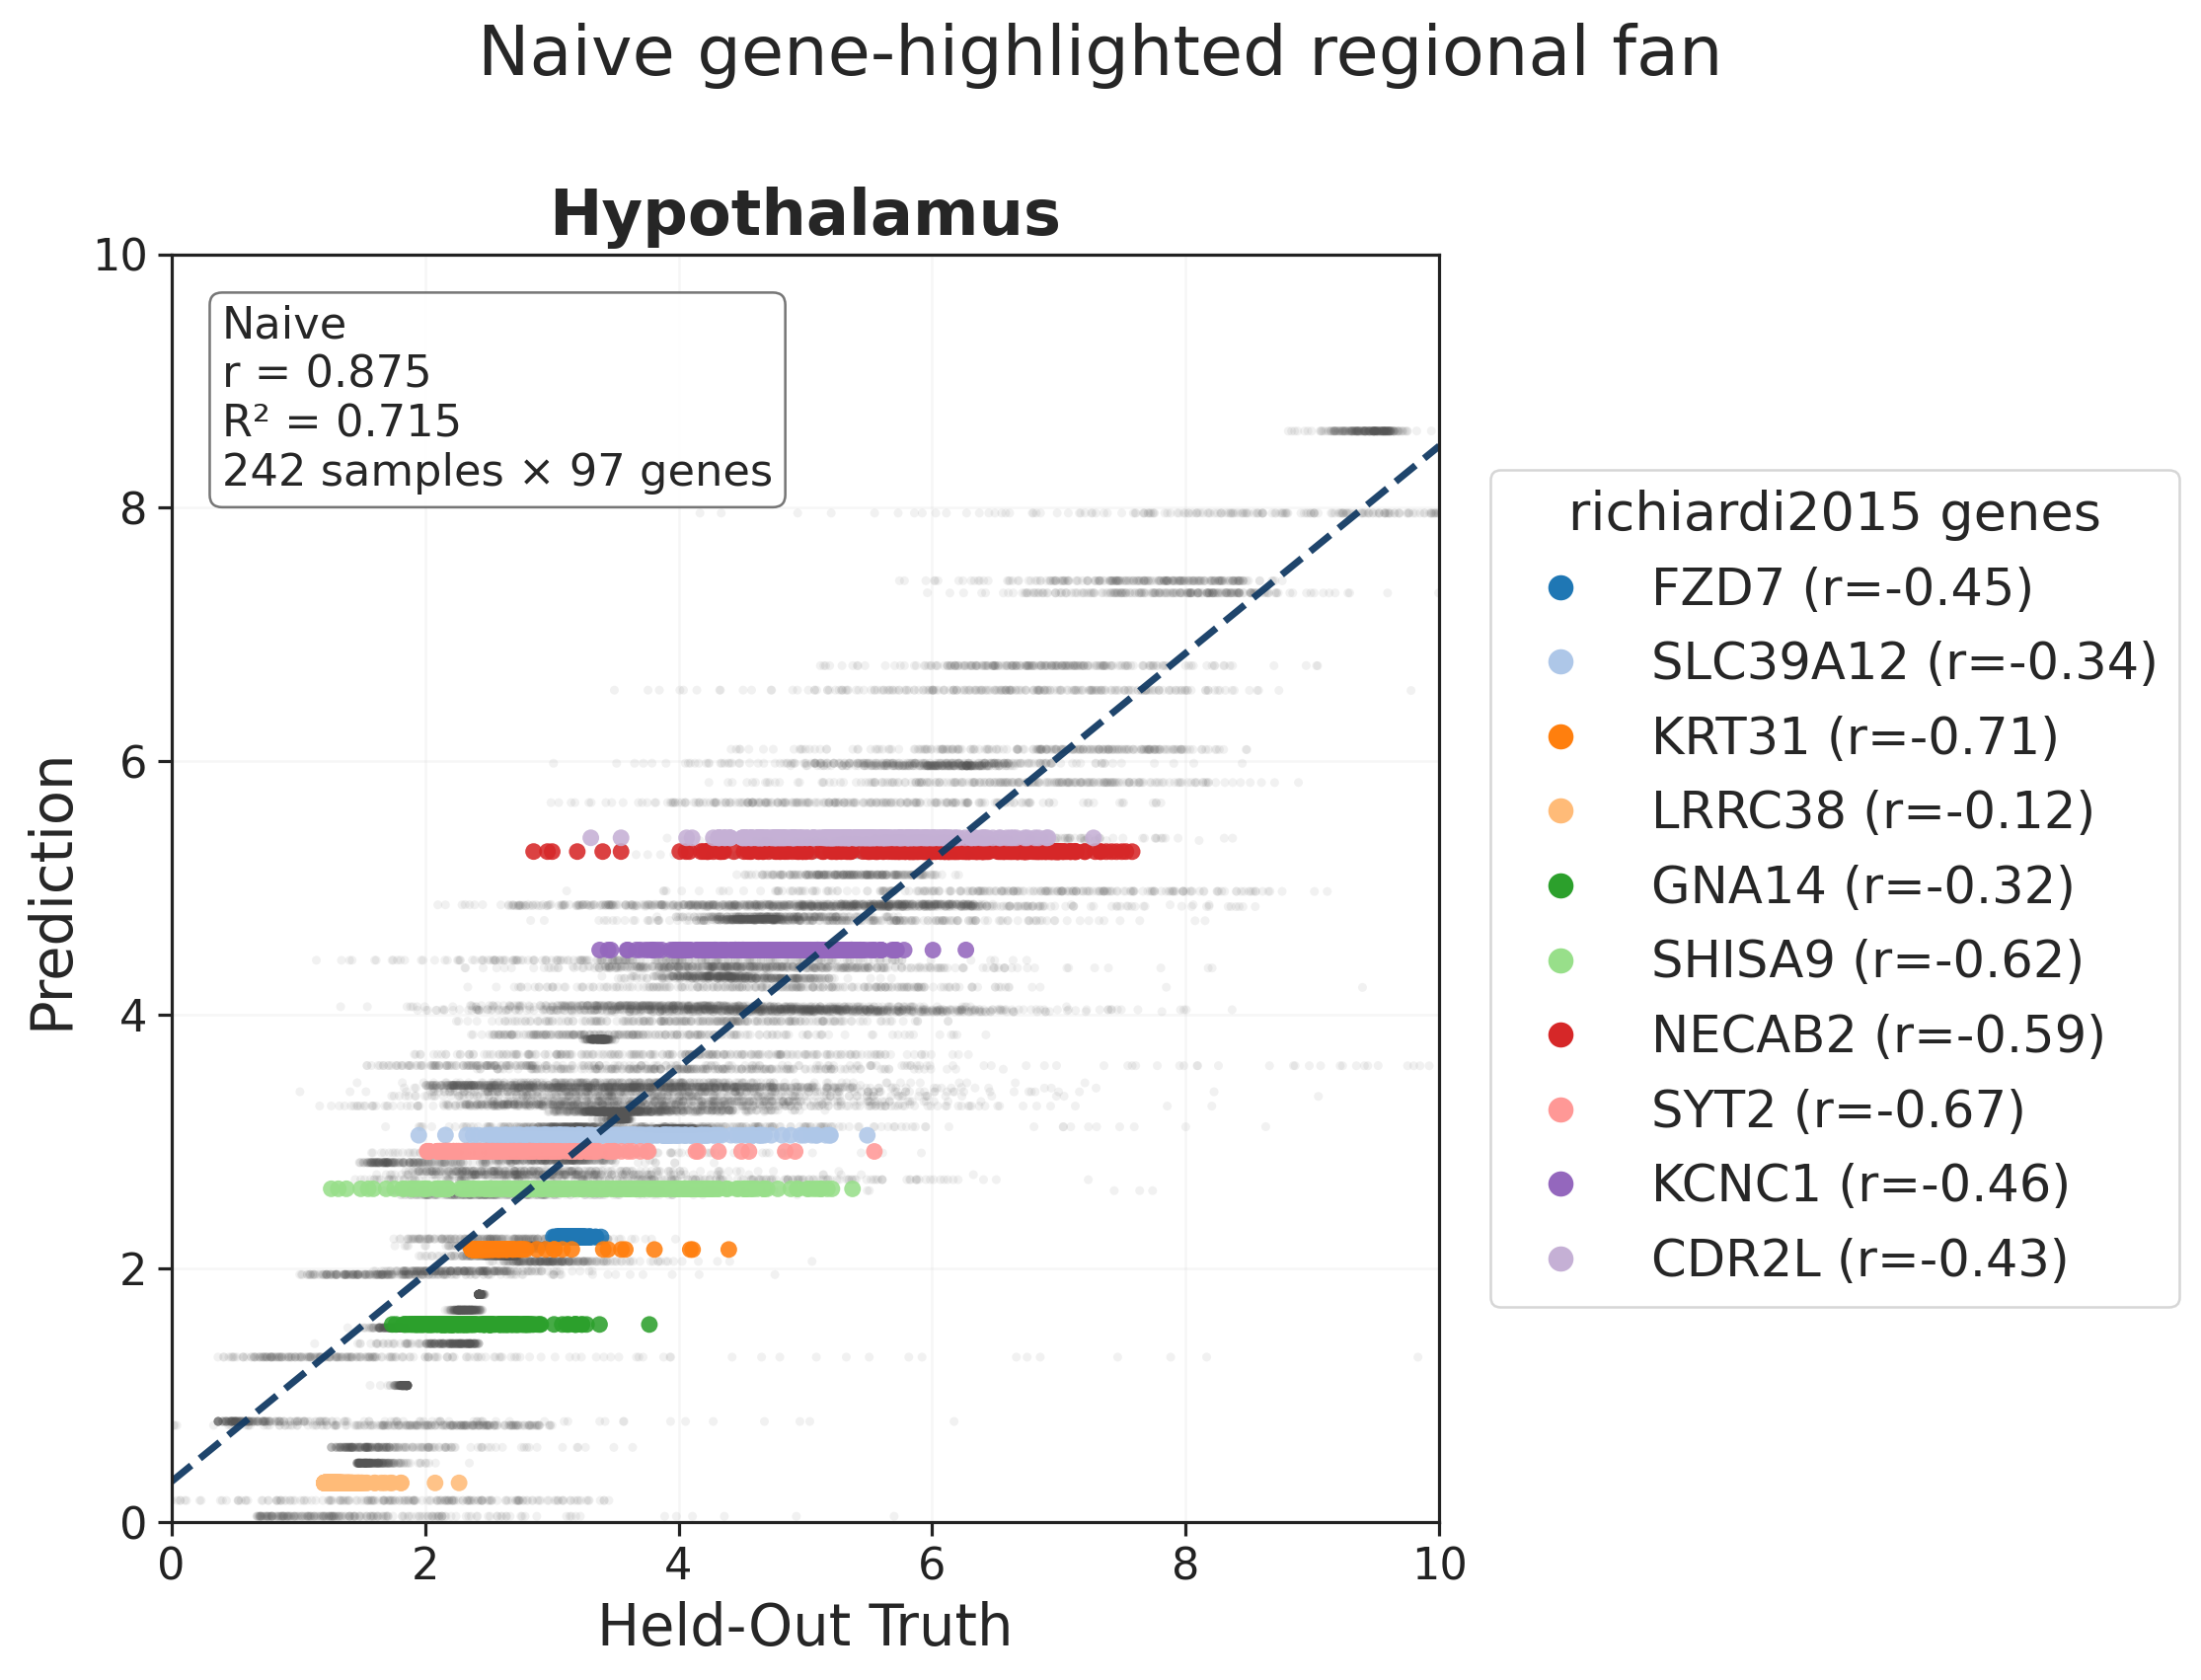

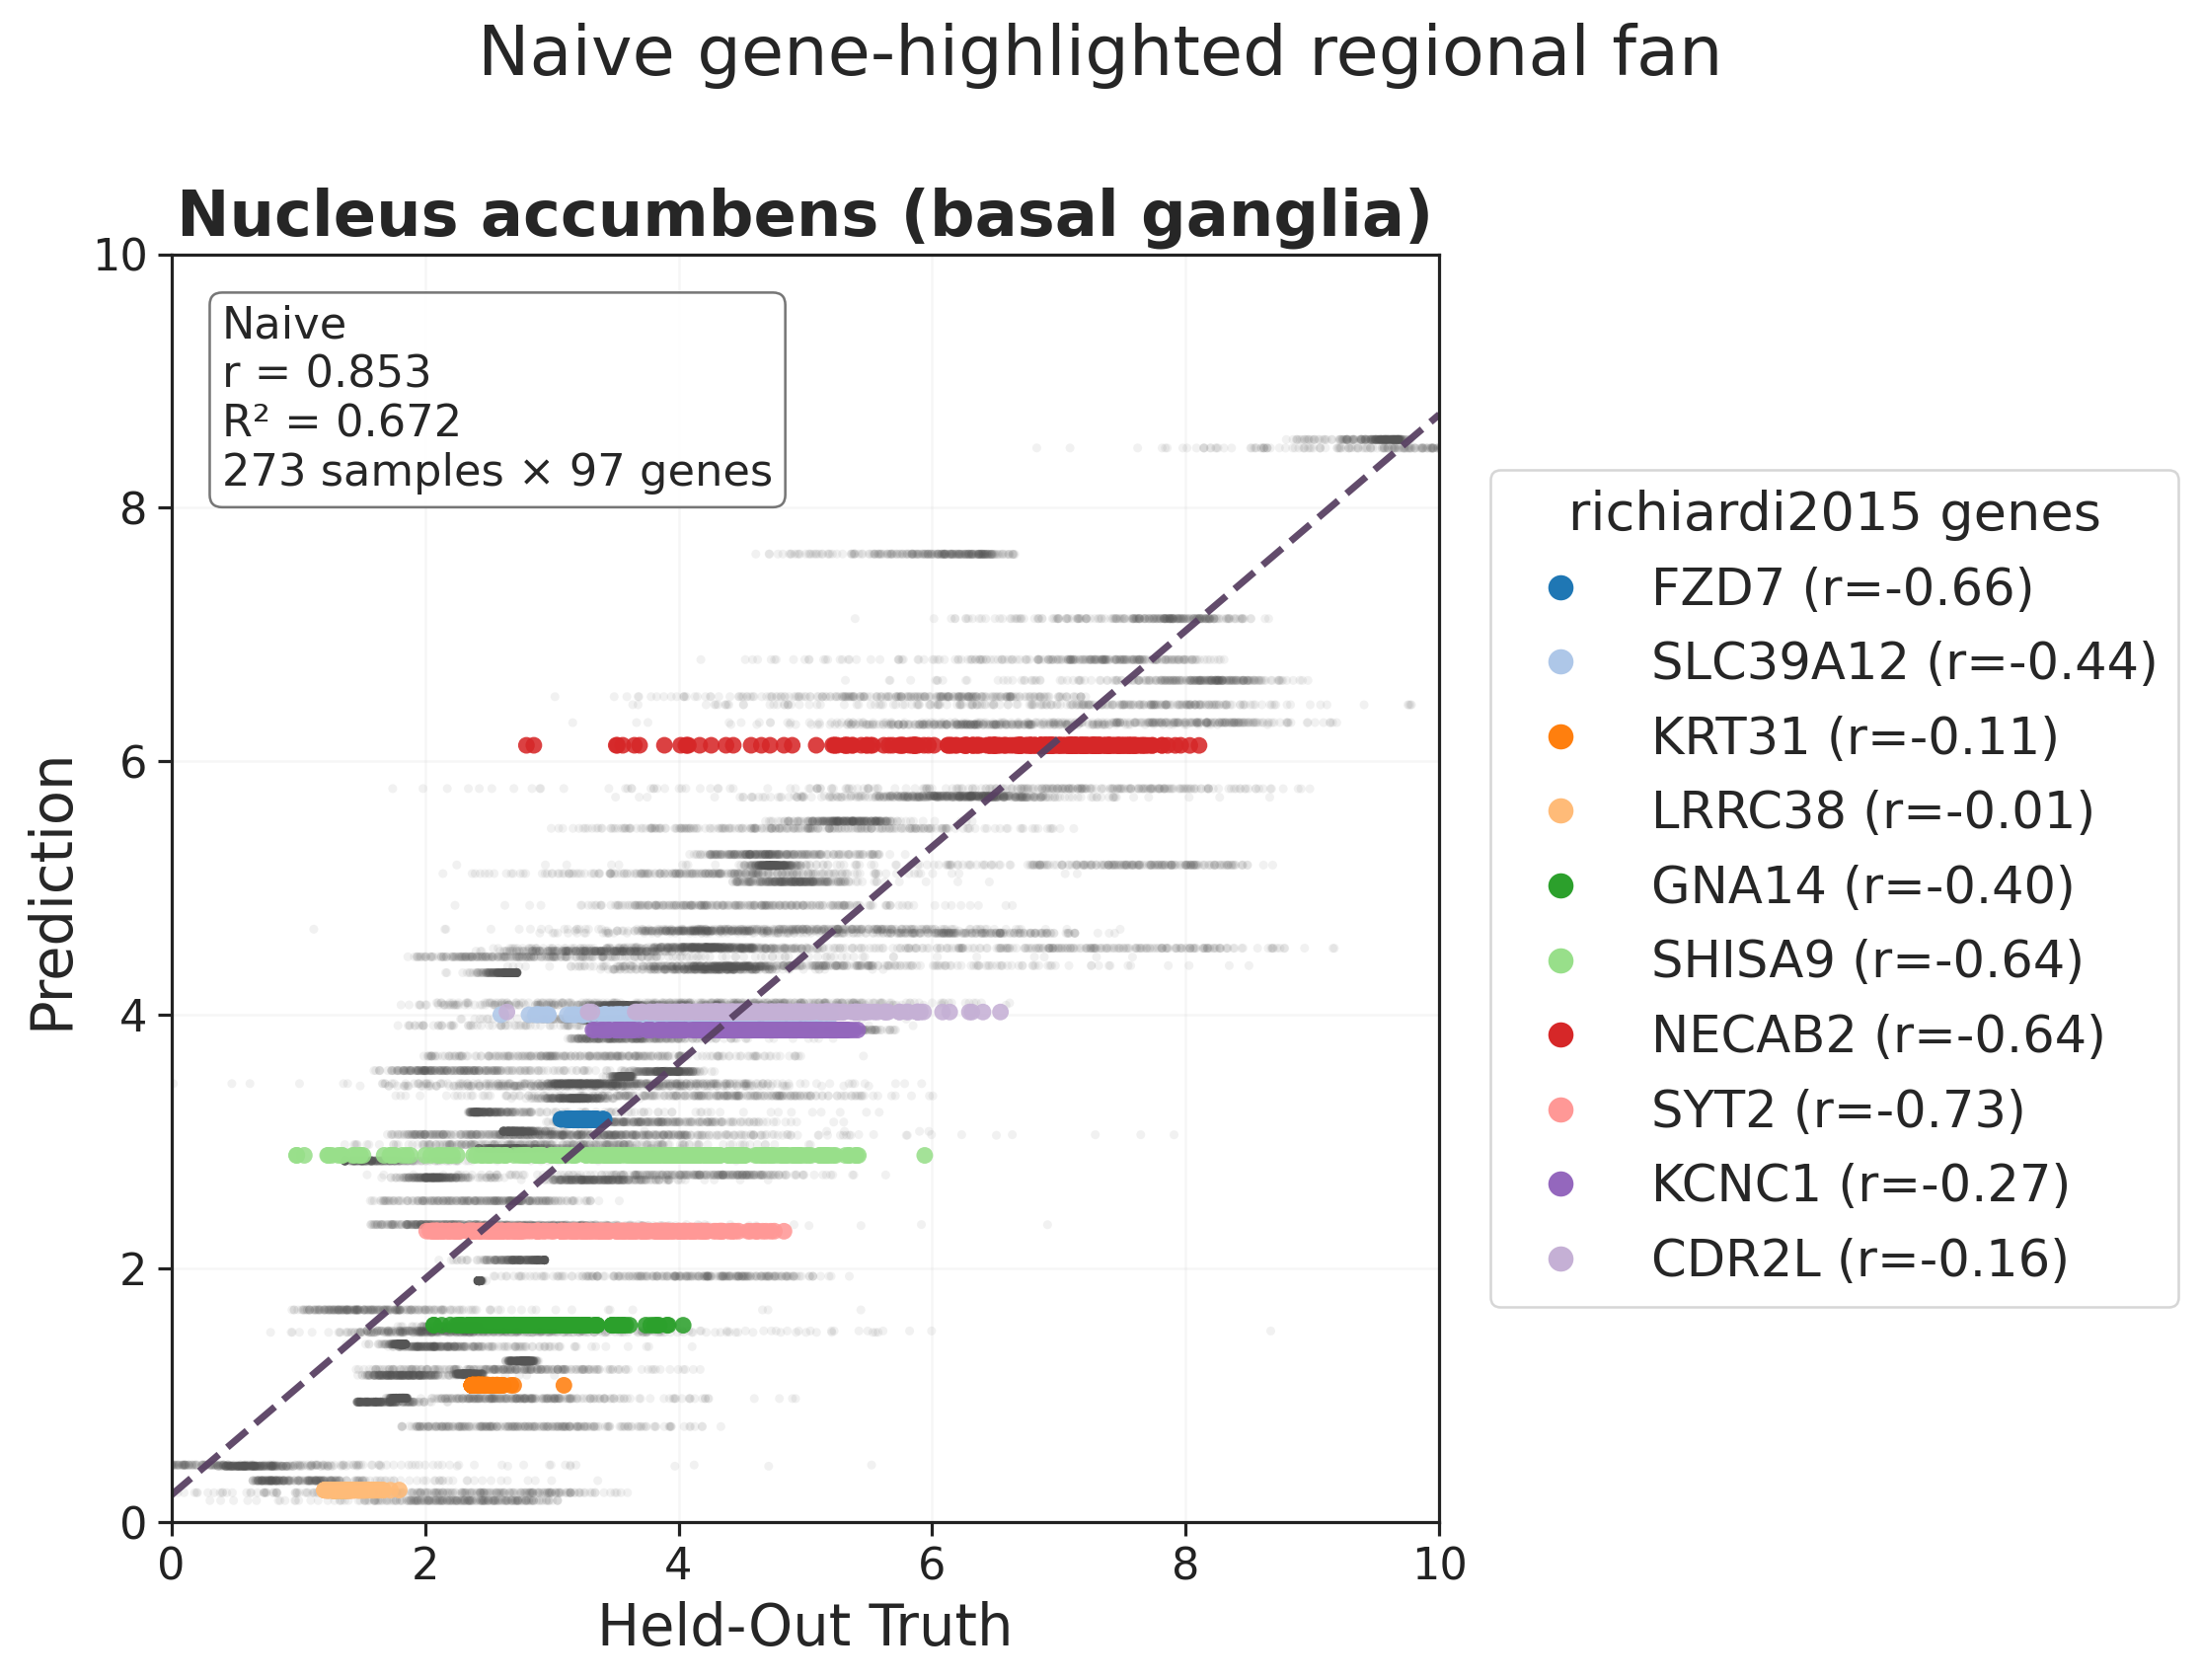

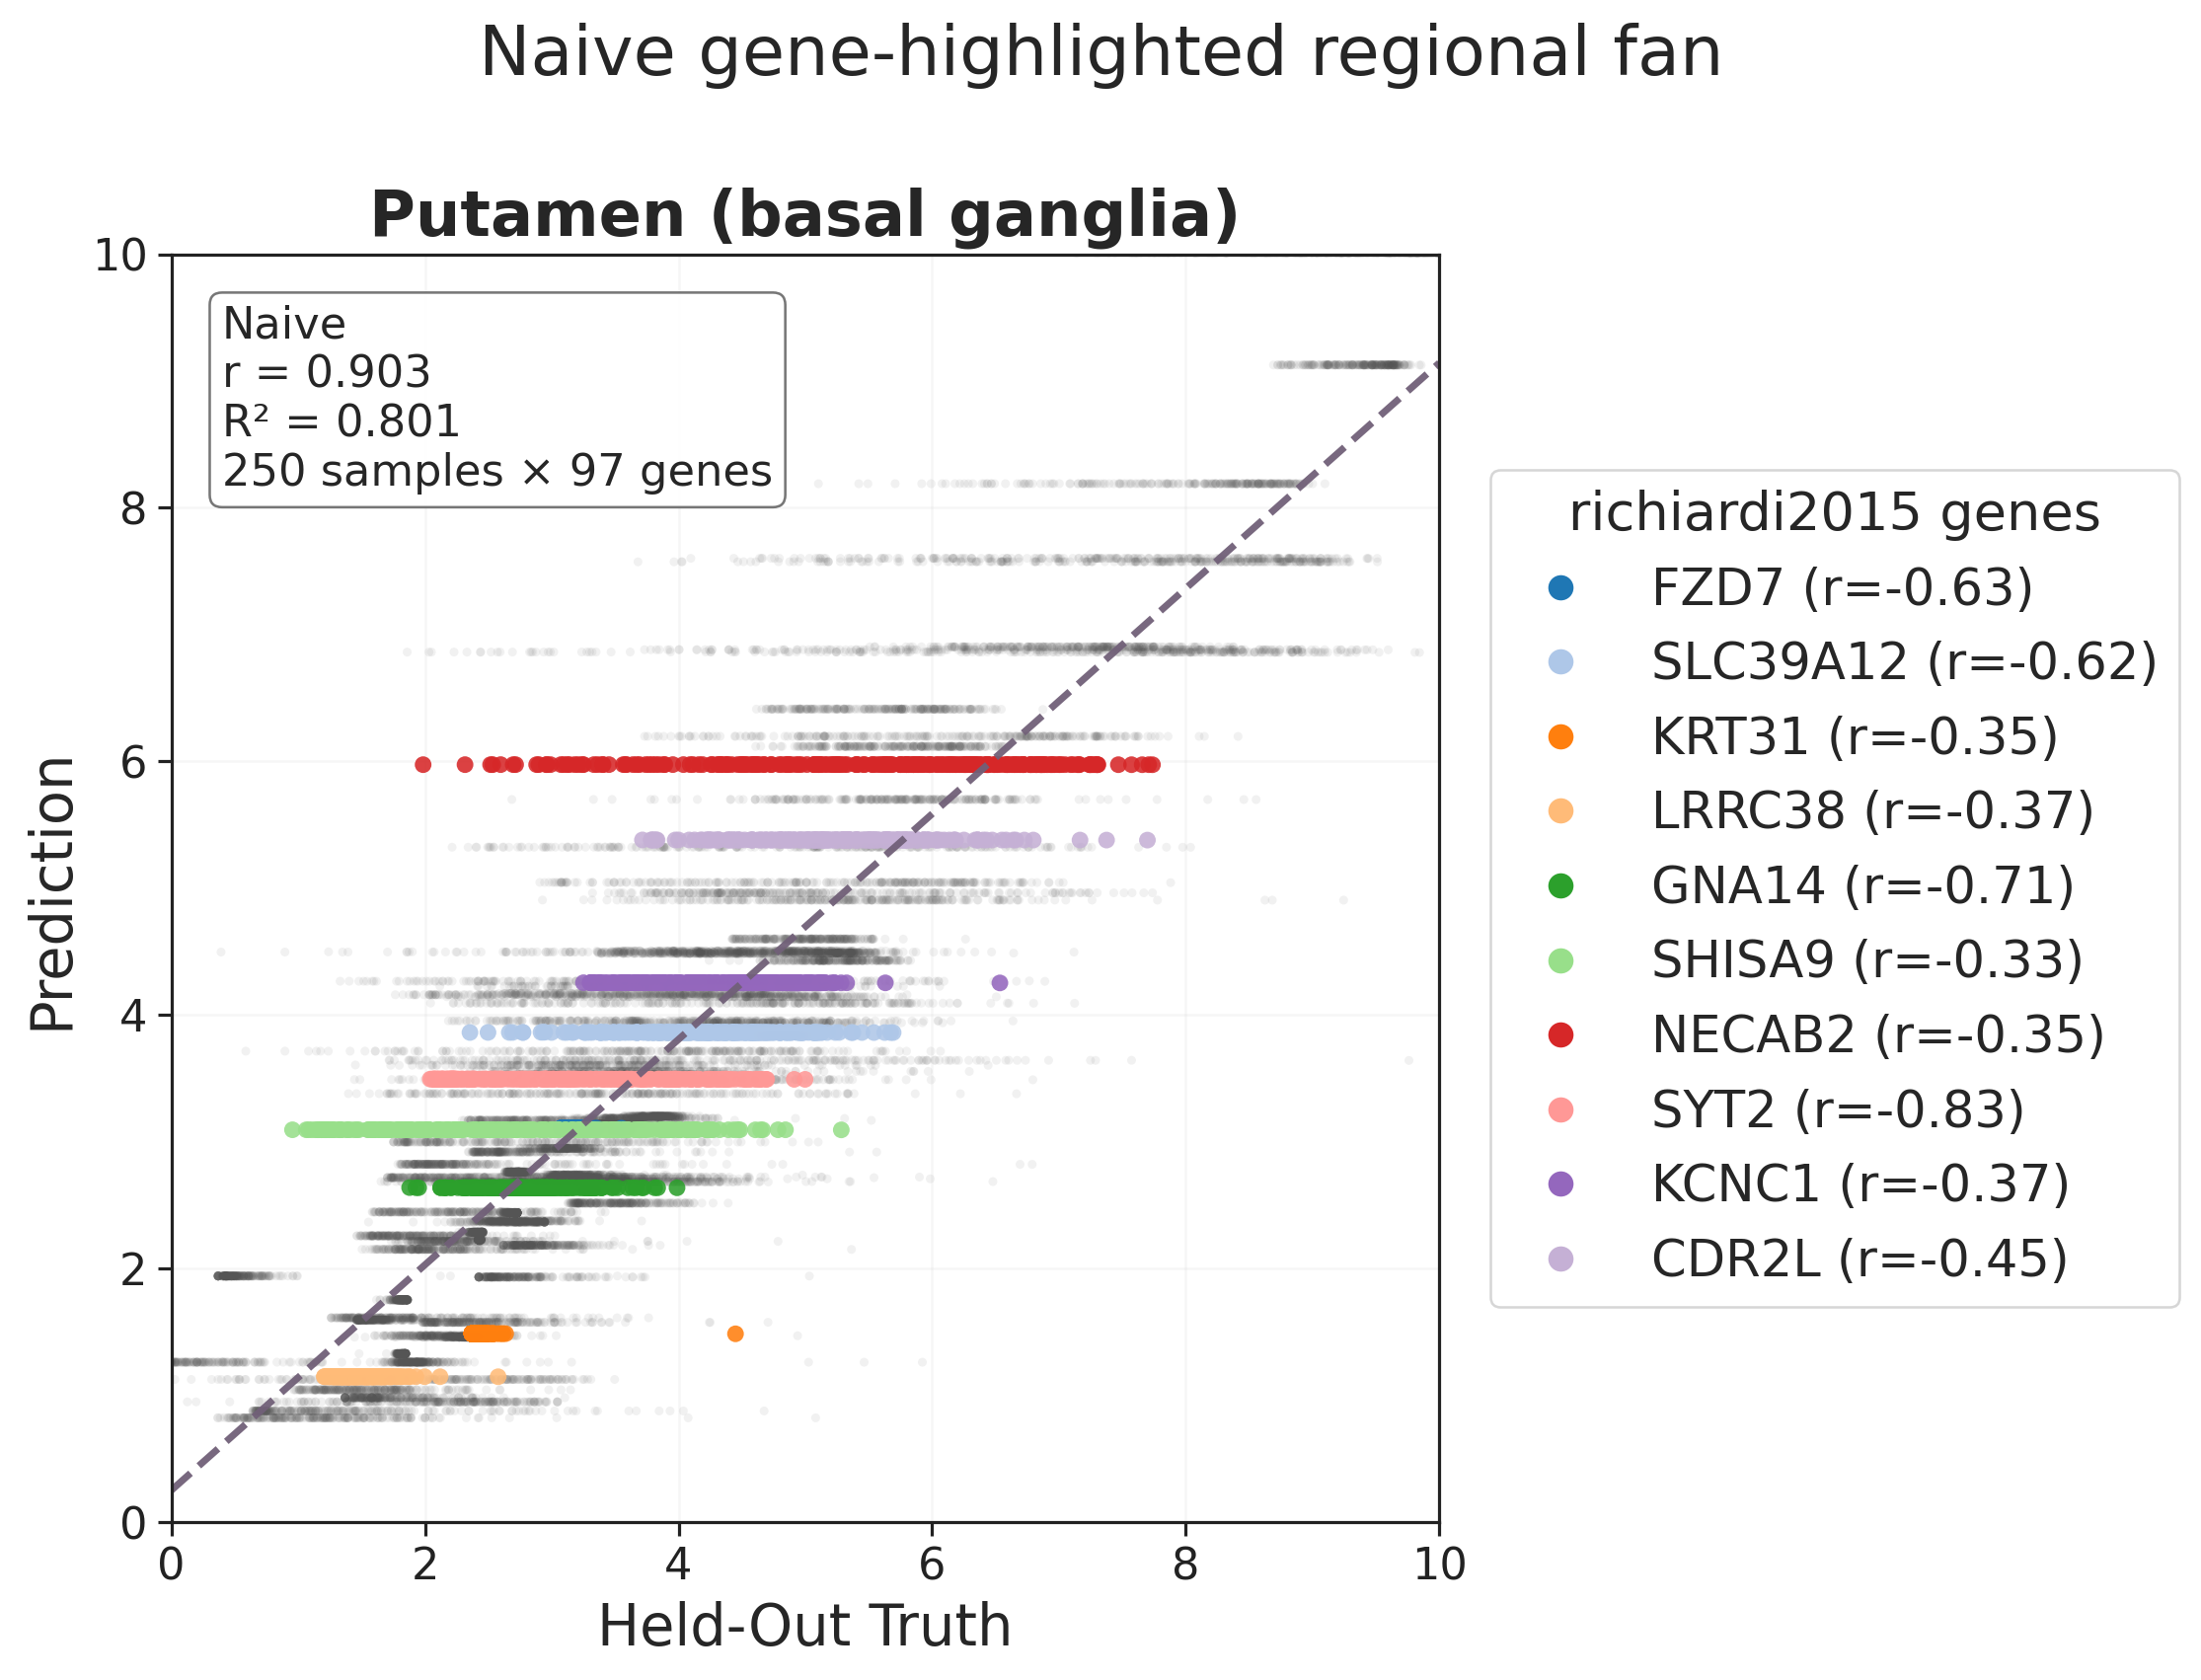

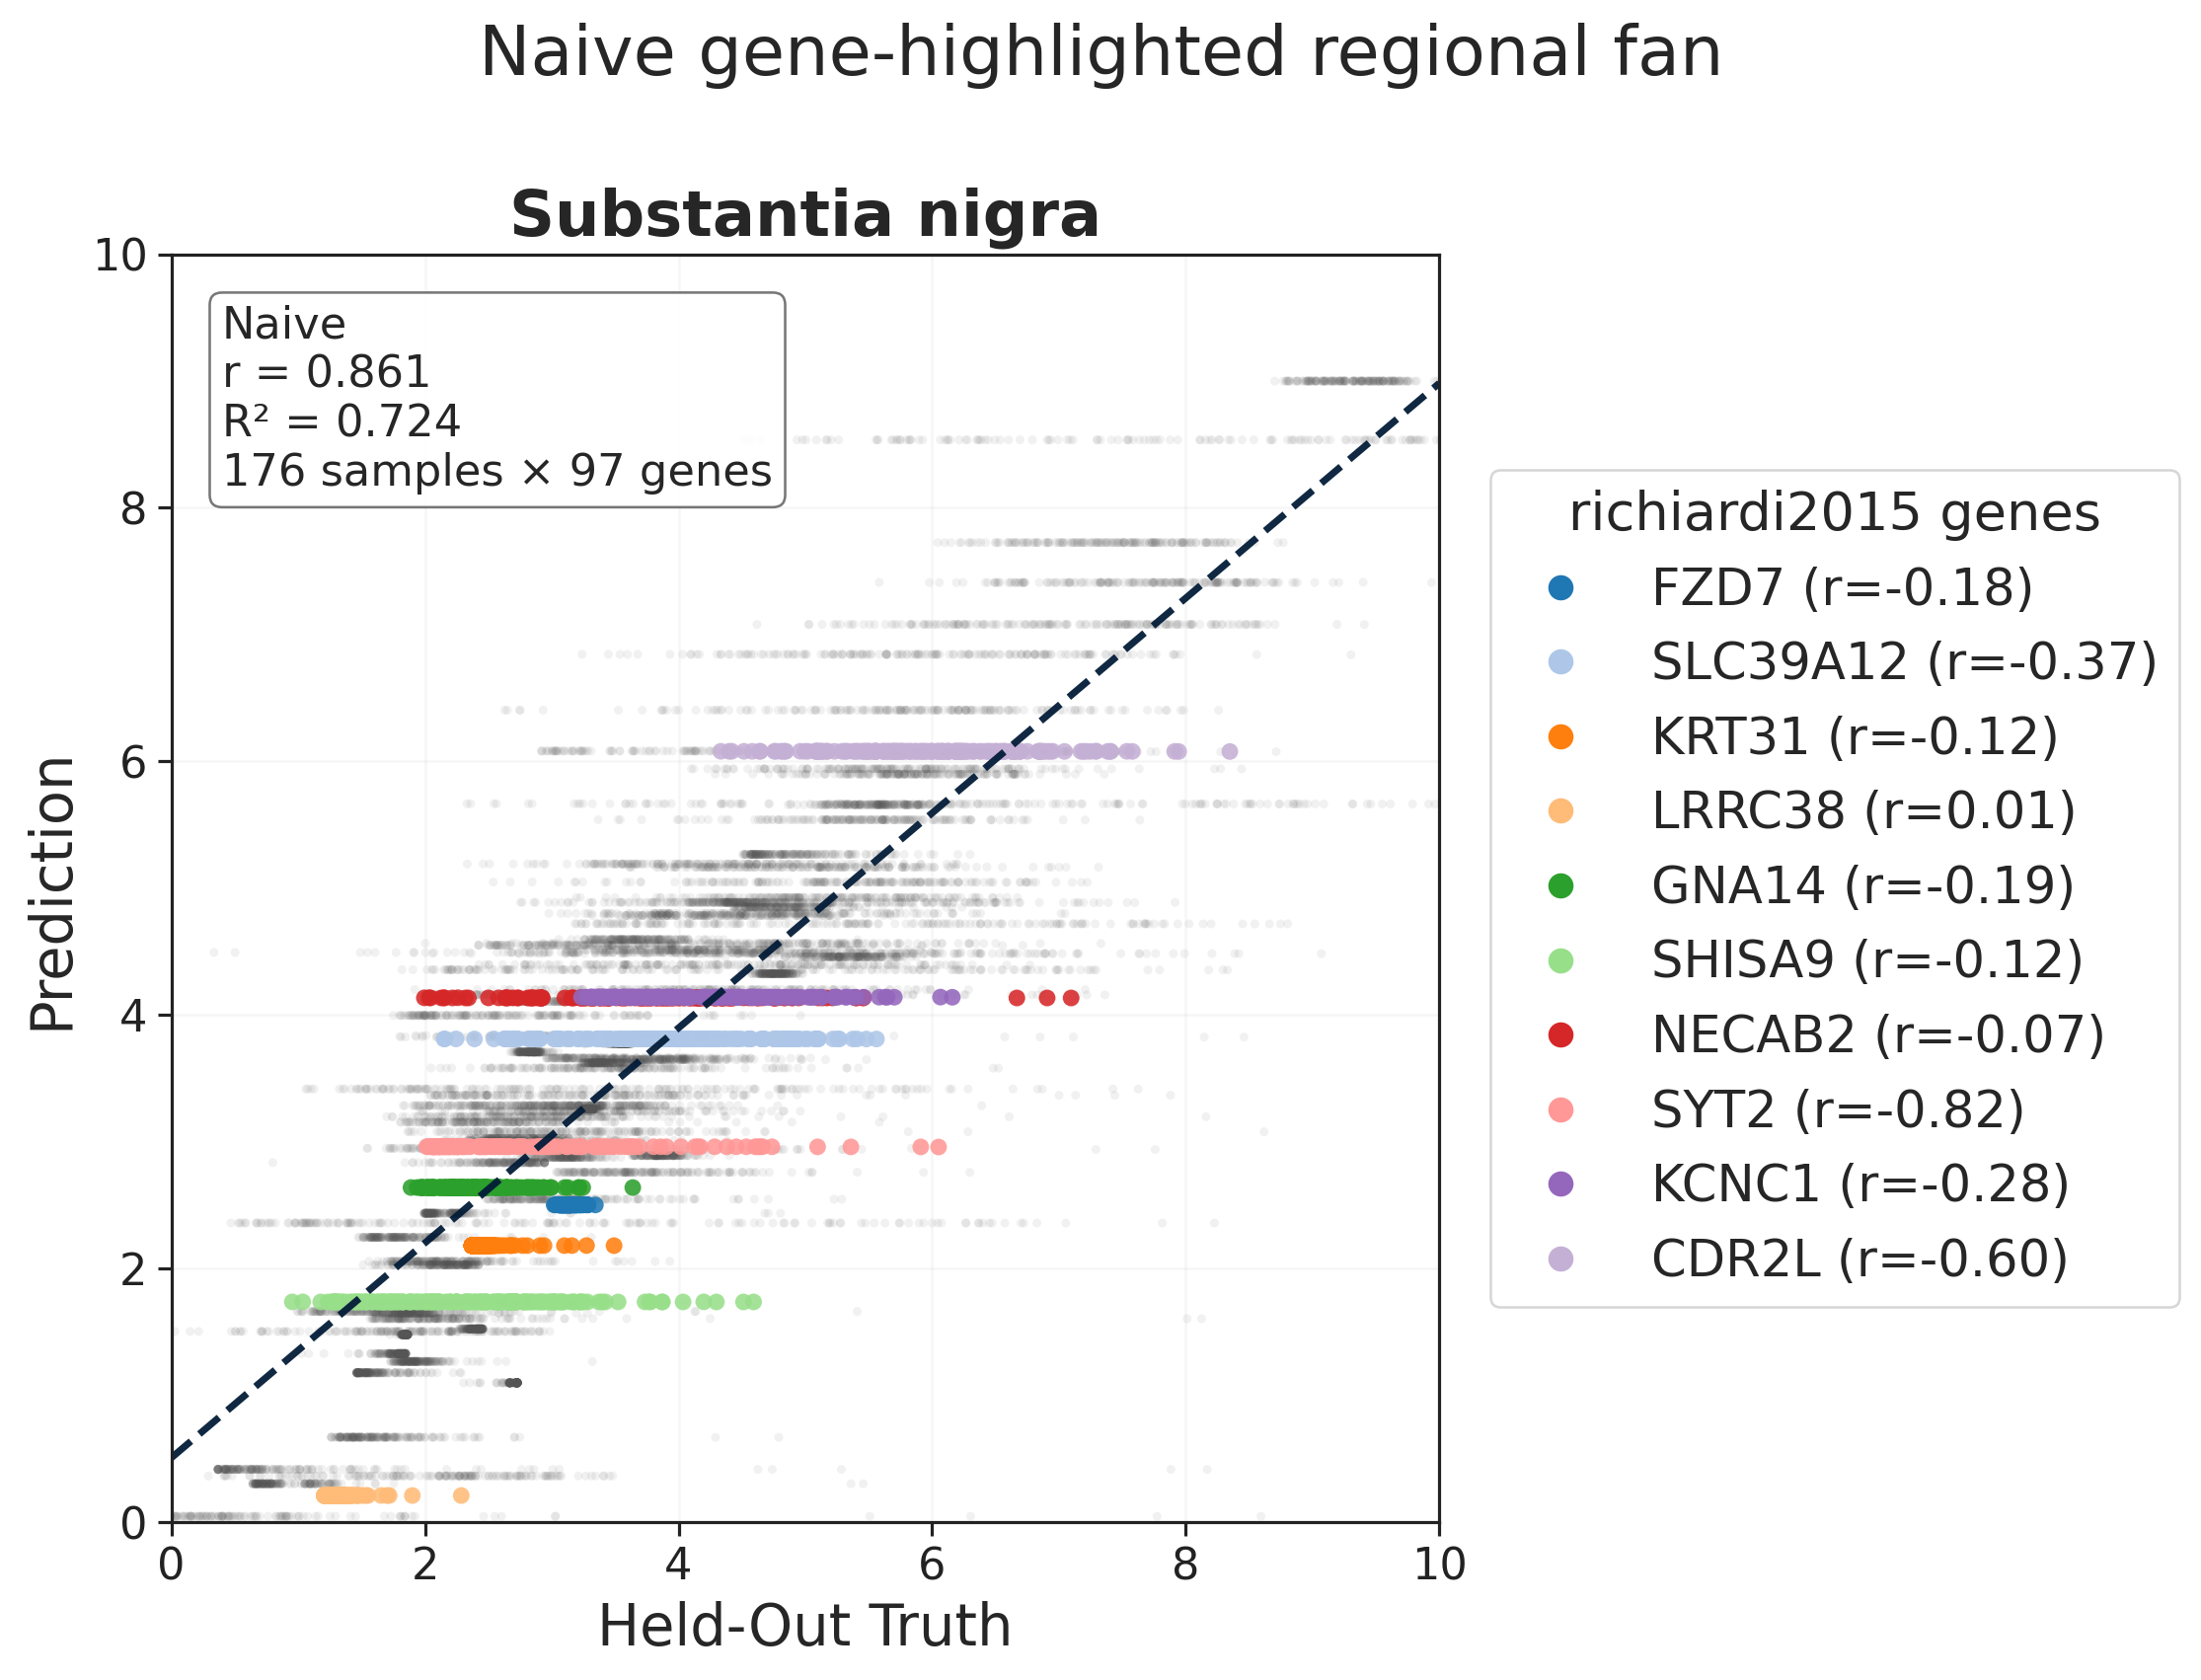

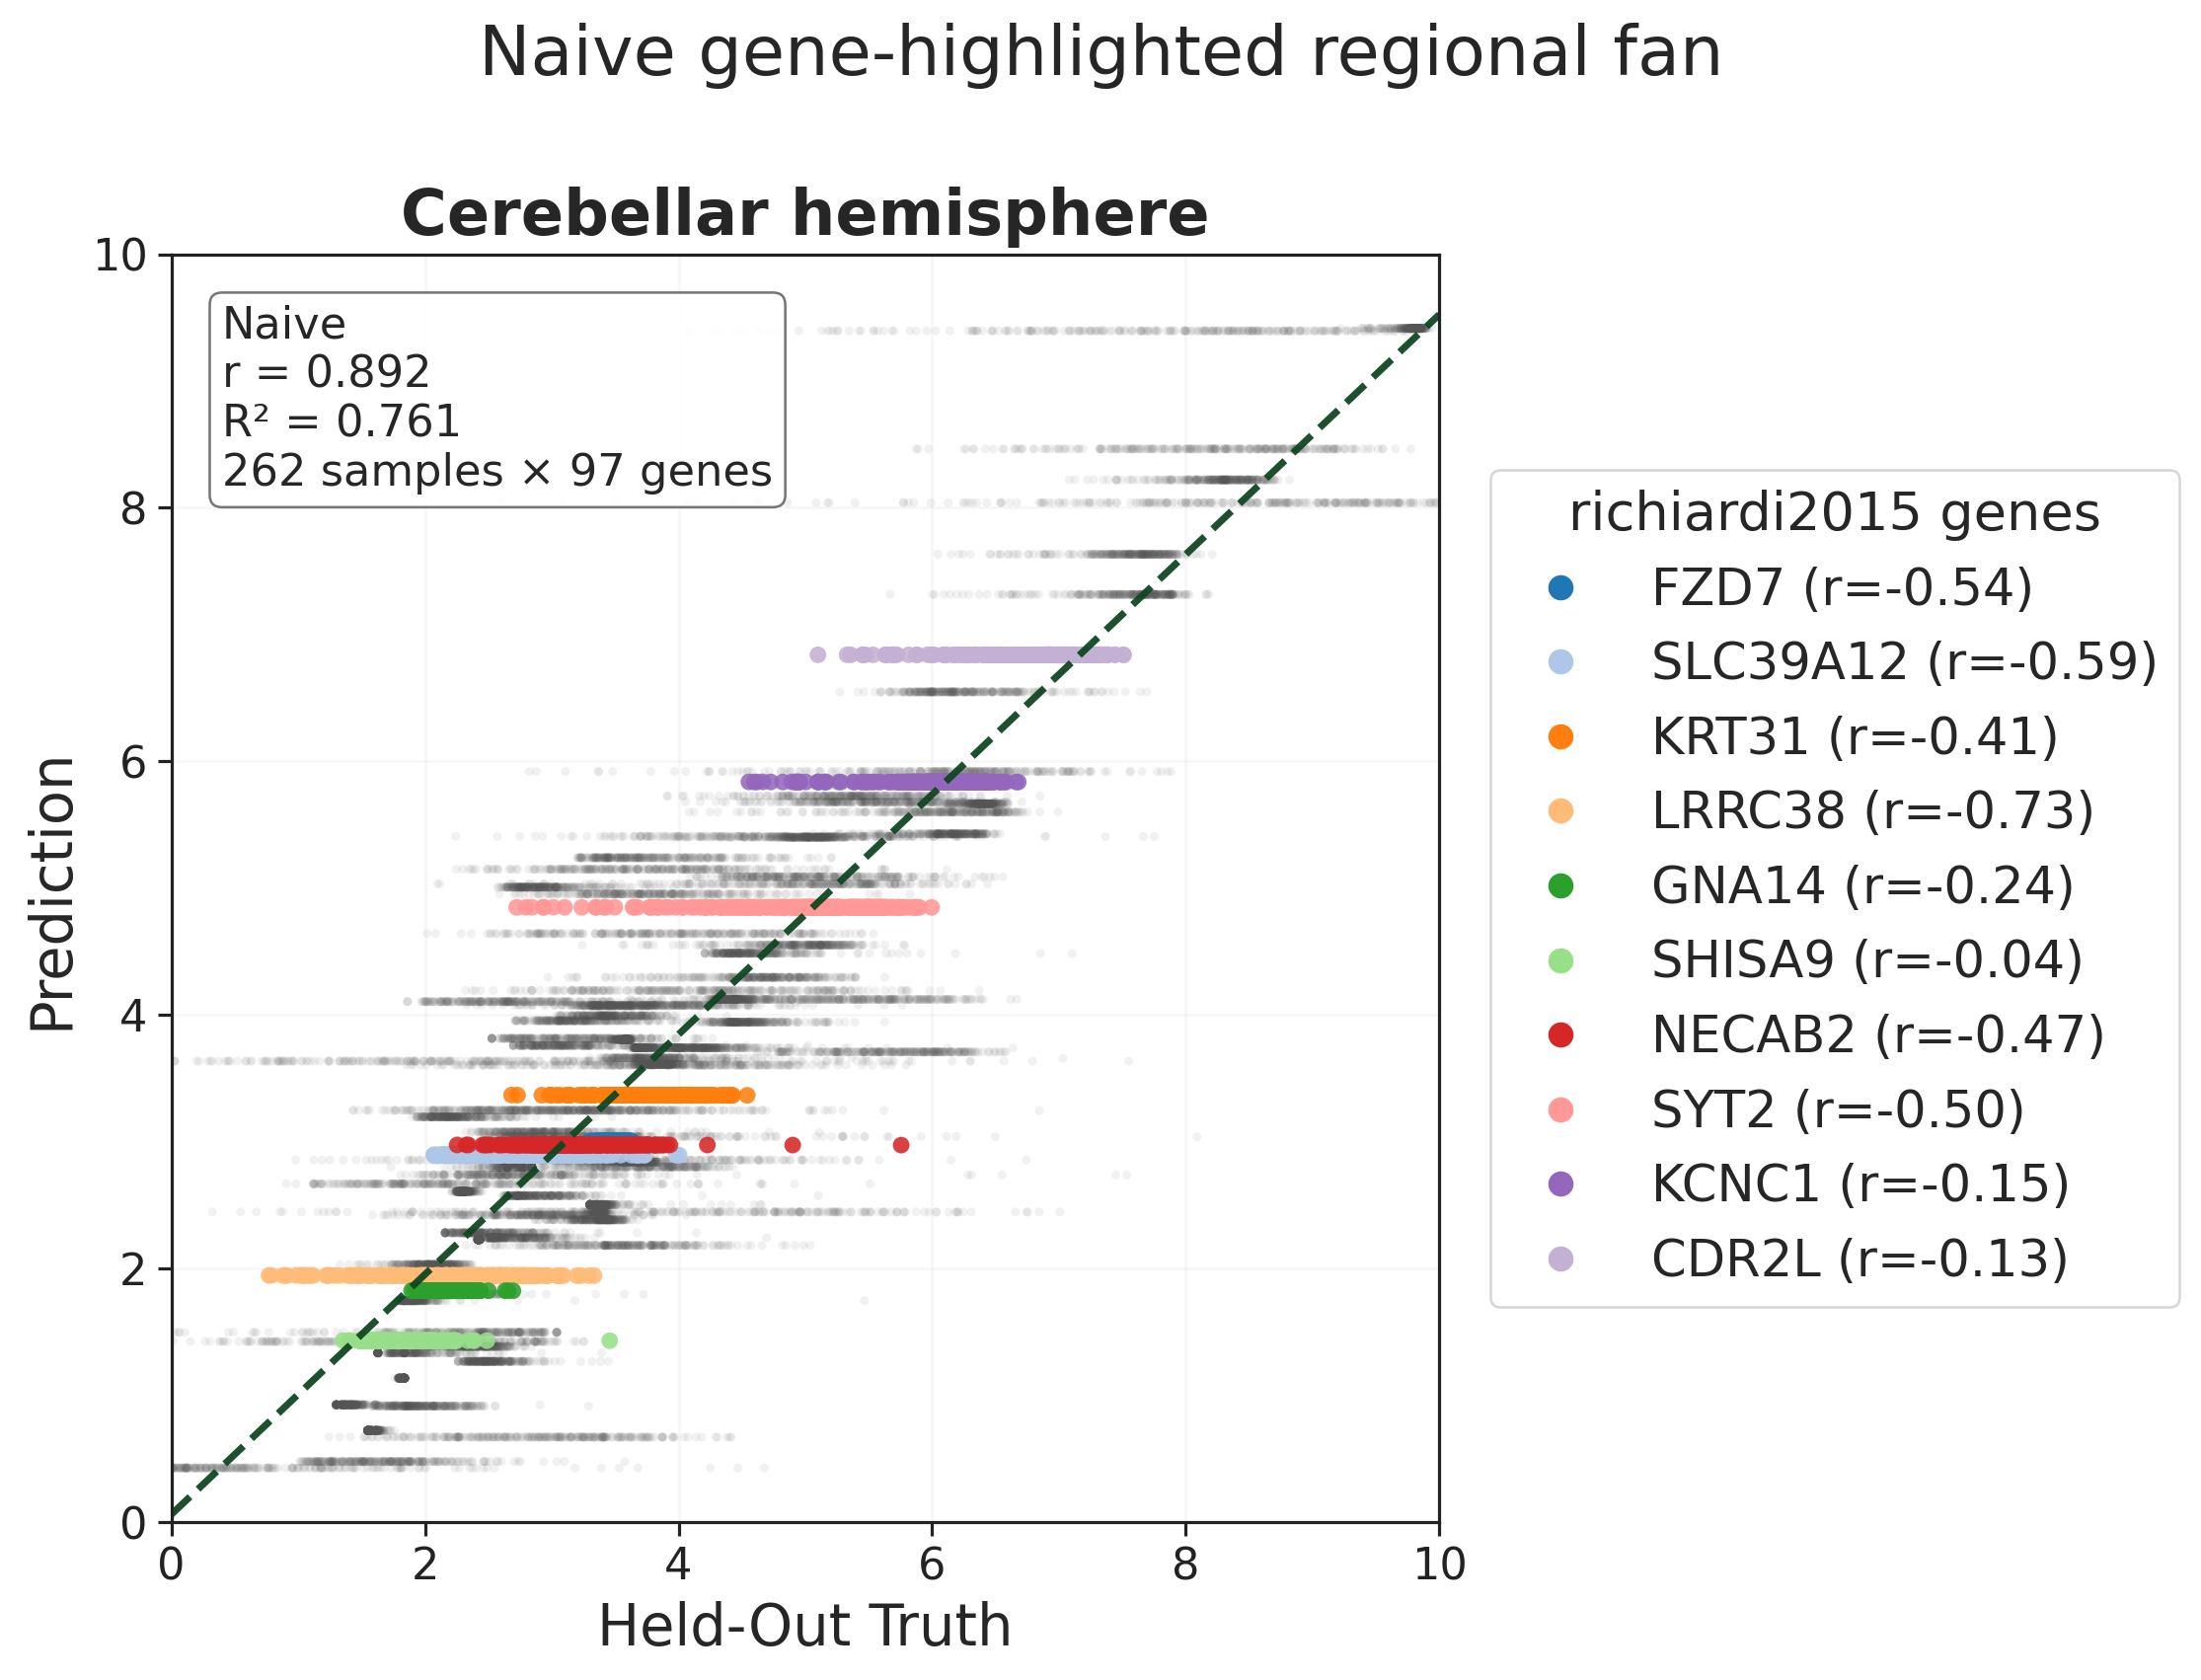

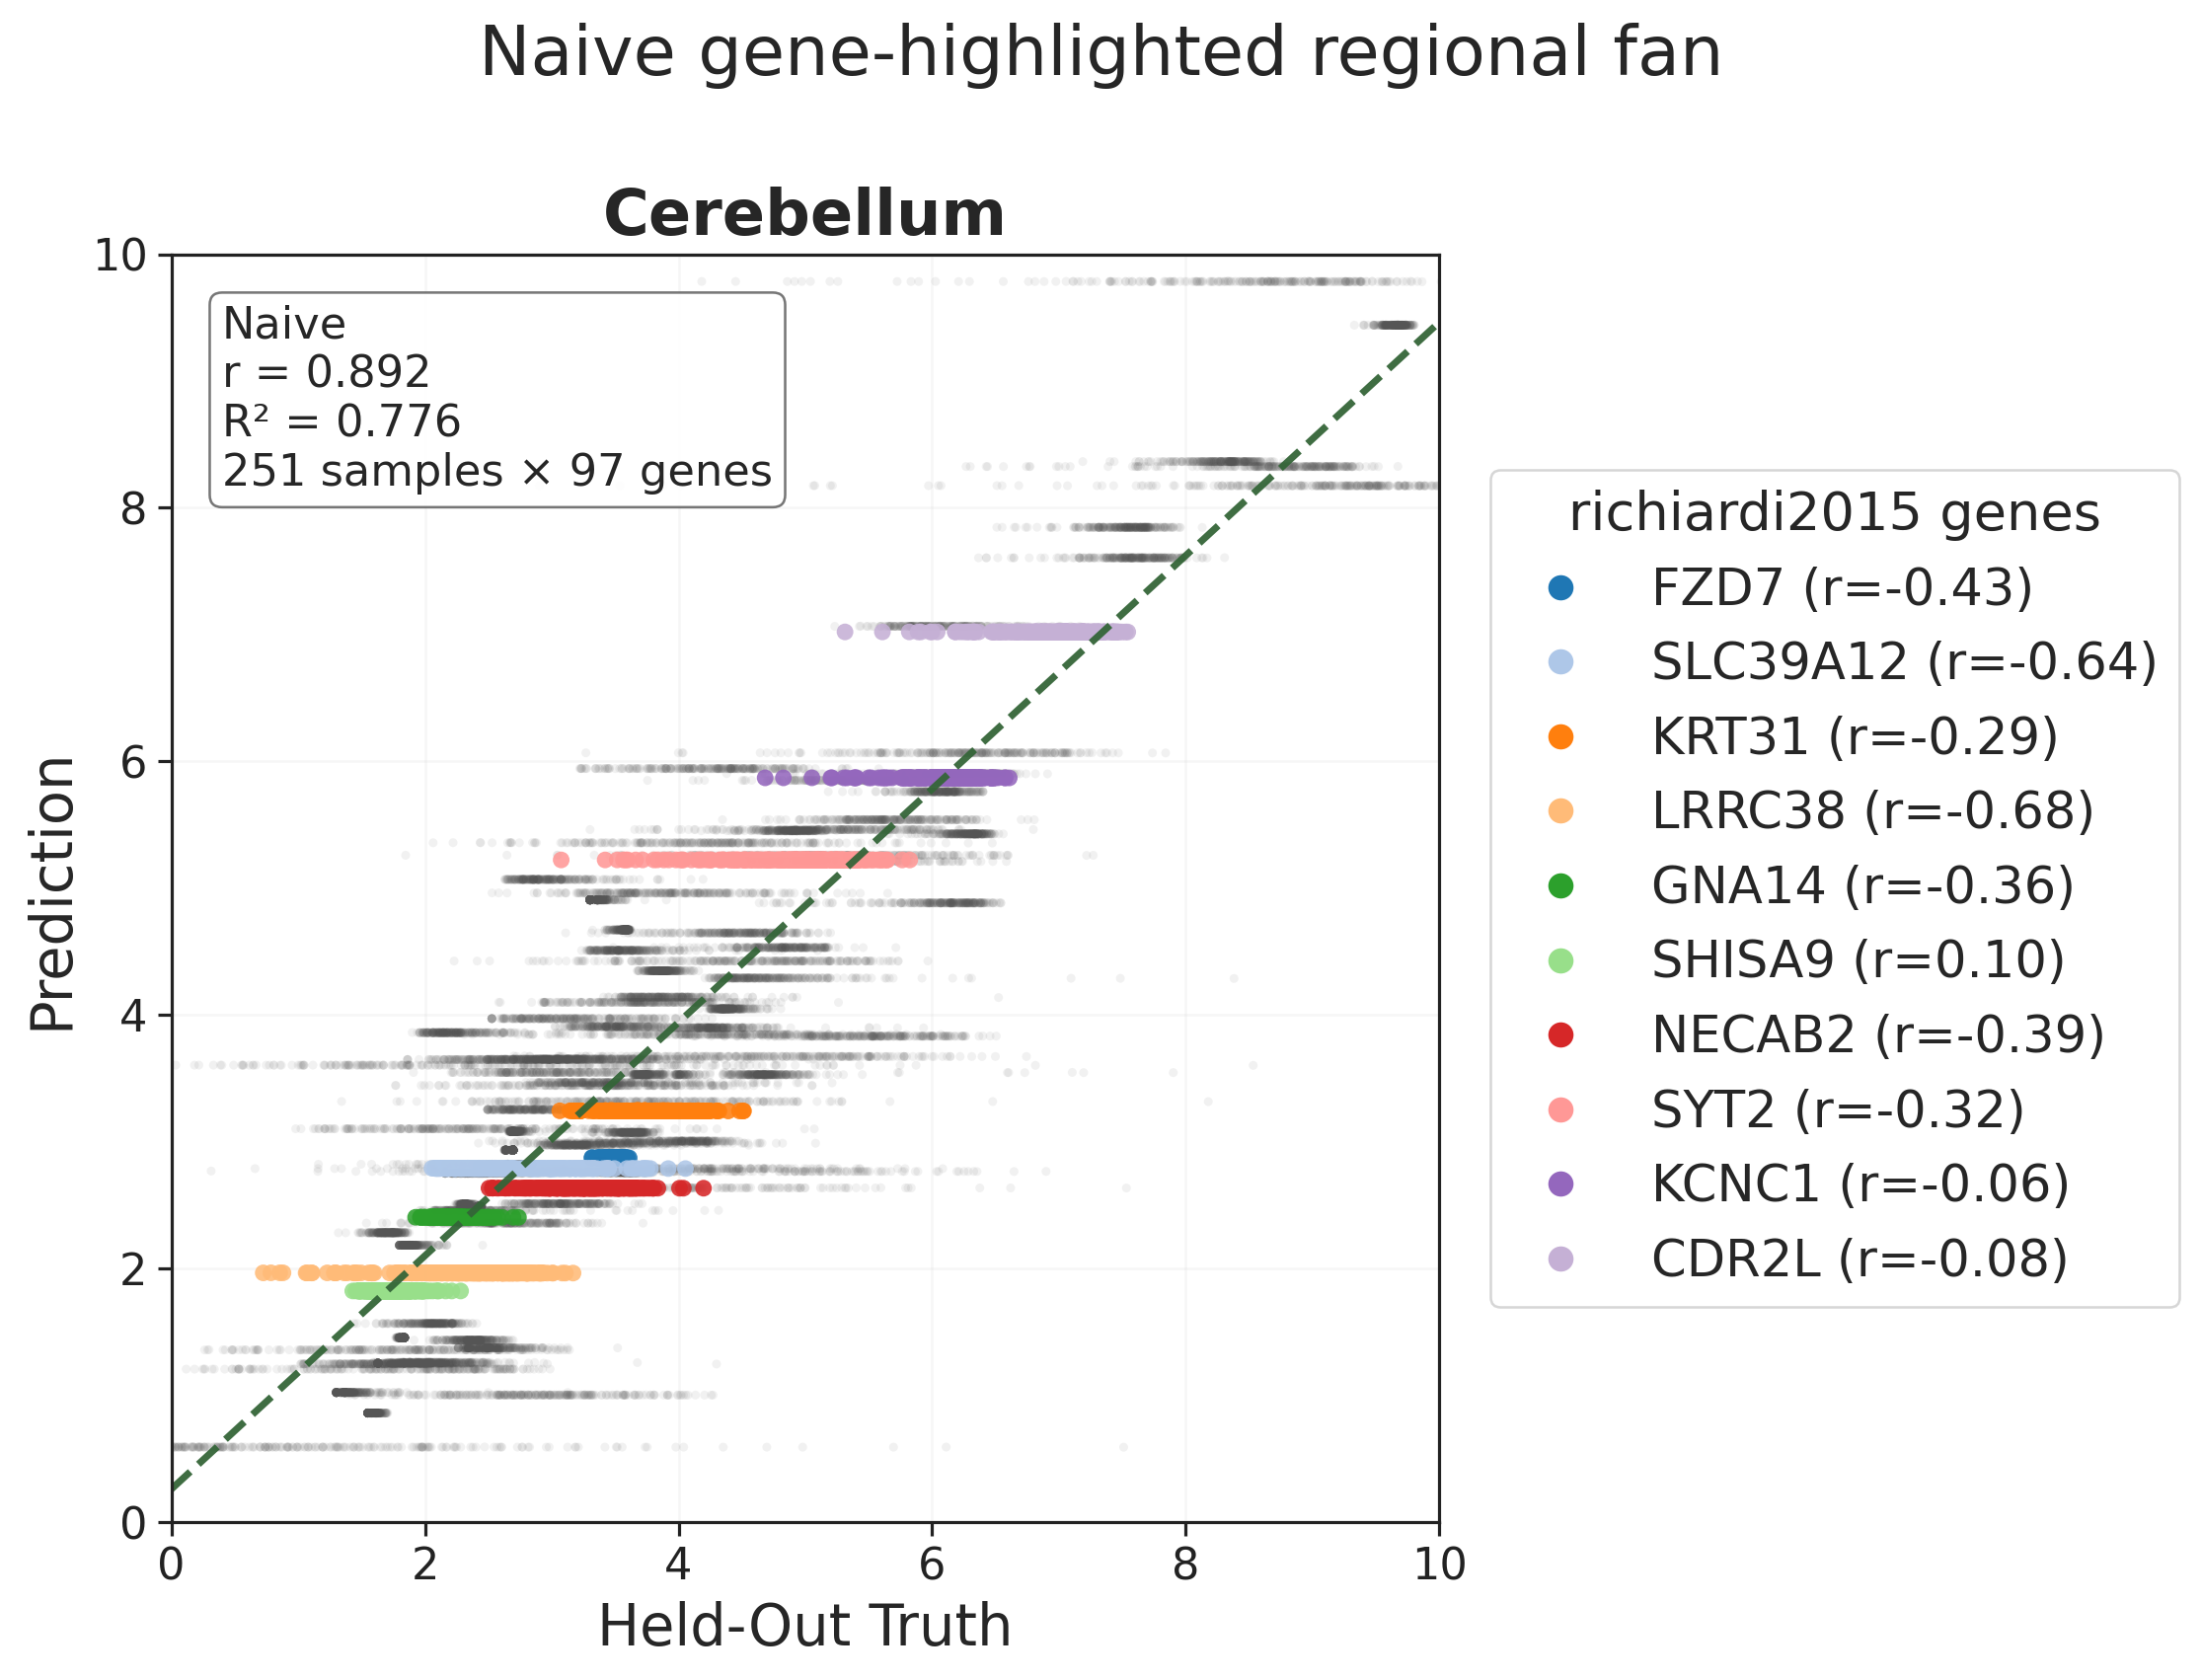

In [19]:
_REGION_FAN_REGION_PALETTE = _region_palette(strat_view)
REGION_FAN_RESOLVED = _region_fan_raw_regions(strat_view, REGION_FAN_REGIONS)
print('regions:', [pretty_gtex_label(r) for r in REGION_FAN_RESOLVED])
for region in REGION_FAN_RESOLVED:
    fig, ax = plot_region_gene_fan(region)
    plt.show()
